# Phân tích dữ liệu phát hiện gian lận (PaySim)

Dataset: `PS_20174392719_1491204439457_log.csv` (~6.36 triệu giao dịch mô phỏng của dịch vụ mobile money).

**Các cột:**
- `step`: mốc thời gian (1 step = 1 giờ)
- `type`: loại giao dịch (PAYMENT, TRANSFER, CASH_OUT, CASH_IN, DEBIT)
- `amount`: số tiền giao dịch
- `nameOrig` / `nameDest`: tài khoản nguồn / đích
- `oldbalanceOrg` / `newbalanceOrig`: số dư nguồn trước/sau
- `oldbalanceDest` / `newbalanceDest`: số dư đích trước/sau
- `isFraud`: nhãn gian lận thực tế (1 = gian lận)
- `isFlaggedFraud`: cờ cảnh báo của hệ thống

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

CSV_PATH = "PS_20174392719_1491204439457_log.csv"

## Module 1 — Business Understanding & Data Generation

### 1.1 Đọc dữ liệu — Nguồn 1 (Kaggle)

In [2]:
# Chỉ định dtype để tiết kiệm bộ nhớ khi đọc ~6.3 triệu dòng
dtypes = {
    "step": "int32",
    "type": "category",
    "amount": "float64",
    "nameOrig": "object",
    "oldbalanceOrg": "float64",
    "newbalanceOrig": "float64",
    "nameDest": "object",
    "oldbalanceDest": "float64",
    "newbalanceDest": "float64",
    "isFraud": "int8",
    "isFlaggedFraud": "int8",
}

df = pd.read_csv(CSV_PATH, dtype=dtypes)
print(f"Shape: {df.shape[0]:,} dòng x {df.shape[1]} cột")
df.head()

Shape: 6,362,620 dòng x 11 cột


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


### 1.2 Sinh dữ liệu tổng hợp (Nguồn 2 — Faker)

Ngoài **nguồn 1** (Kaggle *Online Payments Fraud Detection Dataset* — file CSV ở trên), đồ án yêu cầu sinh thêm **nguồn 2**: dữ liệu ngữ cảnh/hành vi bằng Python (**Faker** + logic nghiệp vụ).

| Nhóm | Trường |
|------|--------|
| Tài khoản | `account_age_days`, `home_country`, `device_fingerprint` |
| Hành vi giao dịch | `hour_of_day`, `is_new_device`, `failed_payment_attempts` |
| Địa lý / địa chỉ | `shipping_billing_mismatch`, `ip_billing_mismatch`, `ip_billing_distance_km` |
| Ngữ cảnh (chỉ EDA) | `channel` (web/mobile/POS/api — không đưa vào mô hình) |

**Logic nghiệp vụ:** giao dịch gian lận có xu hướng đến từ tài khoản mới, thiết bị lạ, nhiều lần thanh toán thất bại, lệch địa chỉ giao/thanh toán và IP ở xa quốc gia thanh toán (kèm nhiễu để giữ tính thực tế, tránh biến thành nhãn hoàn hảo).

In [3]:
from faker import Faker

# Seed cố định để tái lập kết quả
SEED = 42
fake = Faker()
Faker.seed(SEED)
rng = np.random.default_rng(SEED)

# Pool giá trị sinh sẵn bằng Faker (sample nhanh cho ~6.3 triệu dòng)
device_pool = np.array([fake.sha1() for _ in range(5000)])          # vân tay thiết bị
country_pool = np.array(sorted({fake.country() for _ in range(300)}))  # danh sách quốc gia

print(f"Số vân tay thiết bị trong pool: {len(device_pool):,}")
print(f"Số quốc gia trong pool: {len(country_pool)}")

Số vân tay thiết bị trong pool: 5,000
Số quốc gia trong pool: 171


In [4]:
# --- Đặc trưng cấp TÀI KHOẢN (theo nameOrig) ---
# Xác định tài khoản từng dính gian lận để tạo tương quan thực tế (fraud -> tài khoản mới)
acct = (
    df.groupby("nameOrig", observed=True, as_index=False)
      .agg(acct_ever_fraud=("isFraud", "max"))
)
m = len(acct)

# account_age_days: tài khoản gian lận trẻ hơn nhiều
young = rng.gamma(shape=2.0, scale=22.0, size=m)     # mean ~44 ngày
old = rng.gamma(shape=2.0, scale=250.0, size=m)      # mean ~500 ngày
acct["account_age_days"] = np.where(acct["acct_ever_fraud"] == 1, young, old)
acct["account_age_days"] = acct["account_age_days"].clip(1, 3650).round().astype("int32")

# home_country (nước thanh toán) & device_fingerprint (thiết bị thường dùng)
acct["home_country"] = rng.choice(country_pool, size=m)
acct["device_fingerprint"] = rng.choice(device_pool, size=m)

# Gộp lại vào df giao dịch
df = df.merge(
    acct[["nameOrig", "account_age_days", "home_country", "device_fingerprint"]],
    on="nameOrig", how="left",
)
print(f"Đã sinh đặc trưng cho {m:,} tài khoản và gộp vào {len(df):,} giao dịch.")

Đã sinh đặc trưng cho 6,353,307 tài khoản và gộp vào 6,362,620 giao dịch.


In [5]:
# --- Đặc trưng cấp GIAO DỊCH (có tiêm tín hiệu gian lận + nhiễu) ---
n = len(df)
fraud = df["isFraud"].to_numpy(bool)

# Giờ trong ngày suy từ step (1 step = 1 giờ)
df["hour_of_day"] = (df["step"] % 24).astype("int16")

# Lệch địa chỉ giao hàng vs thanh toán
p_ship = np.where(fraud, 0.40, 0.03)
df["shipping_billing_mismatch"] = (rng.random(n) < p_ship).astype("int8")

# Dùng thiết bị lạ (khác device_fingerprint thường dùng)
p_dev = np.where(fraud, 0.55, 0.08)
df["is_new_device"] = (rng.random(n) < p_dev).astype("int8")

# Số lần thanh toán thất bại trước khi thành công (Poisson)
lam = np.where(fraud, 2.2, 0.12)
df["failed_payment_attempts"] = rng.poisson(lam).astype("int16")

# IP khác quốc gia thanh toán + khoảng cách IP -> billing (km)
p_ip = np.where(fraud, 0.50, 0.02)
ip_mismatch = rng.random(n) < p_ip
df["ip_billing_mismatch"] = ip_mismatch.astype("int8")
dist = np.where(ip_mismatch, rng.uniform(500, 8000, n), rng.uniform(0, 80, n))
df["ip_billing_distance_km"] = np.round(dist, 1)

# Kênh giao dịch (channel) — trường ngữ cảnh CHỈ dùng cho EDA (không đưa vào model để tránh nhiễu)
_channels = np.array(["web", "mobile", "POS", "api"])
_fr = np.asarray(fraud).astype(bool)
_P = np.where(_fr[:, None],
              np.array([0.45, 0.25, 0.10, 0.20]),   # gian lận: thiên về web/api
              np.array([0.35, 0.45, 0.15, 0.05]))    # hợp lệ: thiên về mobile
_cdf = np.cumsum(_P, axis=1)
_idx = (rng.random(n)[:, None] > _cdf).sum(axis=1)
df["channel"] = _channels[np.clip(_idx, 0, 3)]
print("Đã sinh trường 'channel' (EDA):", df["channel"].value_counts().to_dict())

synthetic_cols = [
    "account_age_days", "home_country", "device_fingerprint",
    "hour_of_day", "shipping_billing_mismatch", "is_new_device",
    "failed_payment_attempts", "ip_billing_mismatch", "ip_billing_distance_km",
]
print(f"Đã sinh {len(synthetic_cols)} trường rủi ro tổng hợp + 1 trường channel (EDA) = {len(synthetic_cols)+1} trường ngữ cảnh.")
df[synthetic_cols].head()

Đã sinh trường 'channel' (EDA): {'mobile': 2863237, 'web': 2227044, 'POS': 952246, 'api': 320093}
Đã sinh 9 trường rủi ro tổng hợp + 1 trường channel (EDA) = 10 trường ngữ cảnh.


,account_age_days,home_country,device_fingerprint,hour_of_day,shipping_billing_mismatch,is_new_device,failed_payment_attempts,ip_billing_mismatch,ip_billing_distance_km
0,1844,Turkey,3f3c5045fb90ae9ff7193b314a99681d07097a92,1,0,0,0,0,14.0
1,455,Mauritius,a7659a6eeda6238f103ff716cea182608ed2e94d,1,0,0,0,0,75.2
2,22,United States Virgin Islands,8a58b239dabe361913c0d1925f8a620d1b8aaf9d,1,0,1,4,1,7311.7
3,21,Kenya,44499e8236716e2ee9f8f3632593b22e95ac69c5,1,0,0,2,0,72.4
4,115,Lithuania,53b8a856e61e1134420a5306e749c9e2a4111a22,1,0,0,1,0,62.9


In [6]:
# Kiểm chứng: trung bình đặc trưng tổng hợp theo nhãn (chứng minh tính thực tế của tín hiệu)
check_cols = [
    "account_age_days", "shipping_billing_mismatch", "is_new_device",
    "failed_payment_attempts", "ip_billing_mismatch", "ip_billing_distance_km",
]
sanity = df.groupby("isFraud")[check_cols].mean().T
sanity.columns = ["Hợp lệ (0)", "Gian lận (1)"]
print("Trung bình theo nhãn:")
print(sanity.round(3))

Trung bình theo nhãn:
                           Hợp lệ (0)  Gian lận (1)
account_age_days              500.058        44.106
shipping_billing_mismatch       0.030         0.405
is_new_device                   0.080         0.551
failed_payment_attempts         0.120         2.249
ip_billing_mismatch             0.020         0.499
ip_billing_distance_km        123.994      2161.265


### 1.3 Data Dictionary (bắt buộc)

Mọi trường tổng hợp được ghi tài liệu đầy đủ: tên cột, kiểu dữ liệu, đơn vị, khoảng giá trị hợp lệ và logic sinh / giả định nghiệp vụ. File xuất ra `data_dictionary.md`, `data_dictionary.csv` và `data_dictionary.xlsx`.

In [7]:
data_dict_rows = [
    {"column": "account_age_days", "dtype": "int32", "unit": "ngày", "valid_range": "1–3650",
     "generation_logic": "Tuổi tài khoản cấp theo nameOrig, phân phối Gamma; tài khoản từng gian lận trẻ hơn (mean ~44) so với hợp lệ (mean ~500)."},
    {"column": "home_country", "dtype": "category/str", "unit": "-", "valid_range": "~240 quốc gia (Faker)",
     "generation_logic": "Quốc gia thanh toán của tài khoản, chọn ngẫu nhiên đều từ pool quốc gia sinh bởi Faker."},
    {"column": "device_fingerprint", "dtype": "str (SHA1)", "unit": "-", "valid_range": "hash 40 ký tự hex",
     "generation_logic": "Vân tay thiết bị thường dùng của tài khoản, sample từ pool 5.000 hash SHA1 (Faker)."},
    {"column": "hour_of_day", "dtype": "int16", "unit": "giờ", "valid_range": "0–23",
     "generation_logic": "Suy trực tiếp từ step gốc: step % 24 (1 step = 1 giờ)."},
    {"column": "shipping_billing_mismatch", "dtype": "int8 (0/1)", "unit": "cờ nhị phân", "valid_range": "{0, 1}",
     "generation_logic": "Lệch địa chỉ giao hàng vs thanh toán; Bernoulli p=0.40 nếu gian lận, p=0.03 nếu hợp lệ."},
    {"column": "is_new_device", "dtype": "int8 (0/1)", "unit": "cờ nhị phân", "valid_range": "{0, 1}",
     "generation_logic": "Giao dịch từ thiết bị lạ; Bernoulli p=0.55 nếu gian lận, p=0.08 nếu hợp lệ."},
    {"column": "failed_payment_attempts", "dtype": "int16", "unit": "lần", "valid_range": ">= 0 (thực tế 0–~10)",
     "generation_logic": "Số lần thanh toán thất bại trước khi thành công; Poisson(λ=2.2) nếu gian lận, Poisson(λ=0.12) nếu hợp lệ."},
    {"column": "ip_billing_mismatch", "dtype": "int8 (0/1)", "unit": "cờ nhị phân", "valid_range": "{0, 1}",
     "generation_logic": "IP khác quốc gia thanh toán; Bernoulli p=0.50 nếu gian lận, p=0.02 nếu hợp lệ."},
    {"column": "ip_billing_distance_km", "dtype": "float64", "unit": "km", "valid_range": "0–8000",
     "generation_logic": "Khoảng cách IP tới nước thanh toán; Uniform(500, 8000) nếu ip_billing_mismatch=1, ngược lại Uniform(0, 80)."},
]

data_dict_rows.append({
    "column": "channel", "dtype": "category/str", "unit": "-", "valid_range": "{web, mobile, POS, api}",
    "generation_logic": "Kênh giao dịch (contextual, CHỈ dùng cho EDA). Phân phối phụ thuộc nhẹ nhãn: gian lận thiên về web/api, hợp lệ thiên về mobile.",
})

data_dictionary = pd.DataFrame(data_dict_rows)

# Xuất ra 3 định dạng deliverable
data_dictionary.to_csv("data_dictionary.csv", index=False, encoding="utf-8-sig")
with open("data_dictionary.md", "w", encoding="utf-8") as f:
    f.write("# Data Dictionary — Synthetic Features\n\n")
    f.write(data_dictionary.to_markdown(index=False))
data_dictionary.to_excel("data_dictionary.xlsx", index=False)

print("Đã lưu: data_dictionary.md, data_dictionary.csv, data_dictionary.xlsx")
data_dictionary

Đã lưu: data_dictionary.md, data_dictionary.csv, data_dictionary.xlsx


,column,dtype,unit,valid_range,generation_logic
0,account_age_days,int32,ngày,1–3650,"Tuổi tài khoản cấp theo nameOrig, phân phối Ga..."
1,home_country,category/str,-,~240 quốc gia (Faker),"Quốc gia thanh toán của tài khoản, chọn ngẫu n..."
2,device_fingerprint,str (SHA1),-,hash 40 ký tự hex,"Vân tay thiết bị thường dùng của tài khoản, sa..."
3,hour_of_day,int16,giờ,0–23,Suy trực tiếp từ step gốc: step % 24 (1 step =...
4,shipping_billing_mismatch,int8 (0/1),cờ nhị phân,"{0, 1}",Lệch địa chỉ giao hàng vs thanh toán; Bernoull...
5,is_new_device,int8 (0/1),cờ nhị phân,"{0, 1}",Giao dịch từ thiết bị lạ; Bernoulli p=0.55 nếu...
6,failed_payment_attempts,int16,lần,>= 0 (thực tế 0–~10),Số lần thanh toán thất bại trước khi thành côn...
7,ip_billing_mismatch,int8 (0/1),cờ nhị phân,"{0, 1}",IP khác quốc gia thanh toán; Bernoulli p=0.50 ...
8,ip_billing_distance_km,float64,km,0–8000,Khoảng cách IP tới nước thanh toán; Uniform(50...
9,channel,category/str,-,"{web, mobile, POS, api}","Kênh giao dịch (contextual, CHỈ dùng cho EDA)...."


### 1.4 Bài toán nghiệp vụ & KPI

**Câu hỏi:** giao dịch nào có khả năng gian lận, và cân bằng thế nào giữa **chặn gian lận** và **không gây ma sát** cho khách hợp lệ?

**KPI theo dõi:**
- **Fraud rate** — tỉ lệ giao dịch gian lận (mức độ mất cân bằng & quy mô rủi ro).
- **False-positive rate (FPR)** — tỉ lệ giao dịch hợp lệ bị chặn nhầm (đo ma sát khách hàng).
- **Financial loss avoided** — số tiền gian lận chặn được nhờ mô hình (giá trị kinh doanh).

Baseline dưới đây định lượng *rủi ro gốc*; FPR và loss-avoided được tối ưu ở **mục 5.4**.

In [8]:
# KPI baseline (rủi ro gốc, trước làm sạch)
n_txn = len(df)
n_fraud = int(df["isFraud"].sum())
fraud_amount = df.loc[df["isFraud"] == 1, "amount"].sum()
print(f"Tổng giao dịch:                  {n_txn:,}")
print(f"Số gian lận:                     {n_fraud:,}")
print(f"Fraud rate:                      {n_fraud/n_txn*100:.3f}%")
print(f"Tổng tiền gian lận (rủi ro gốc): {fraud_amount:,.0f}")
print(f"TB / giao dịch gian lận:         {fraud_amount/max(n_fraud,1):,.0f}")

Tổng giao dịch:                  6,362,620
Số gian lận:                     8,213
Fraud rate:                      0.129%
Tổng tiền gian lận (rủi ro gốc): 12,056,415,428
TB / giao dịch gian lận:         1,467,967


## Module 2 — Phân tích khám phá dữ liệu (EDA)

### 2.1 Thông tin tổng quan & chất lượng dữ liệu

In [9]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 21 columns):
 #   Column                     Dtype   
---  ------                     -----   
 0   step                       int32   
 1   type                       category
 2   amount                     float64 
 3   nameOrig                   object  
 4   oldbalanceOrg              float64 
 5   newbalanceOrig             float64 
 6   nameDest                   object  
 7   oldbalanceDest             float64 
 8   newbalanceDest             float64 
 9   isFraud                    int8    
 10  isFlaggedFraud             int8    
 11  account_age_days           int32   
 12  home_country               str     
 13  device_fingerprint         str     
 14  hour_of_day                int16   
 15  shipping_billing_mismatch  int8    
 16  is_new_device              int8    
 17  failed_payment_attempts    int16   
 18  ip_billing_mismatch        int8    
 19  ip_billing_distance_km     float

In [10]:
# Kiểm tra giá trị thiếu và trùng lặp
print("Số giá trị thiếu theo cột:")
print(df.isna().sum())
print(f"\nSố dòng trùng lặp hoàn toàn: {df.duplicated().sum():,}")

Số giá trị thiếu theo cột:


step                         0
type                         0
amount                       0
nameOrig                     0
oldbalanceOrg                0
newbalanceOrig               0
nameDest                     0
oldbalanceDest               0
newbalanceDest               0
isFraud                      0
isFlaggedFraud               0
account_age_days             0
home_country                 0
device_fingerprint           0
hour_of_day                  0
shipping_billing_mismatch    0
is_new_device                0
failed_payment_attempts      0
ip_billing_mismatch          0
ip_billing_distance_km       0
channel                      0
dtype: int64



Số dòng trùng lặp hoàn toàn: 0


In [11]:
# Thống kê mô tả các cột số
df.describe().T

,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00
isFlaggedFraud,6362620.0,2.514687e-06,1.585775e-03,0.0,0.00,0.000,0.000000e+00,1.000000e+00
account_age_days,6362620.0,4.994690e+02,3.539138e+02,1.0,240.00,419.000,6.730000e+02,3.650000e+03
hour_of_day,6362620.0,1.532145e+01,4.321799e+00,0.0,12.00,16.000,1.900000e+01,2.300000e+01


### 2.2 Phân bố nhãn gian lận (mất cân bằng lớp)

           count  percent
isFraud                  
0        6354407  99.8709
1           8213   0.1291

Tỉ lệ gian lận: 0.129%  ->  dữ liệu mất cân bằng nghiêm trọng


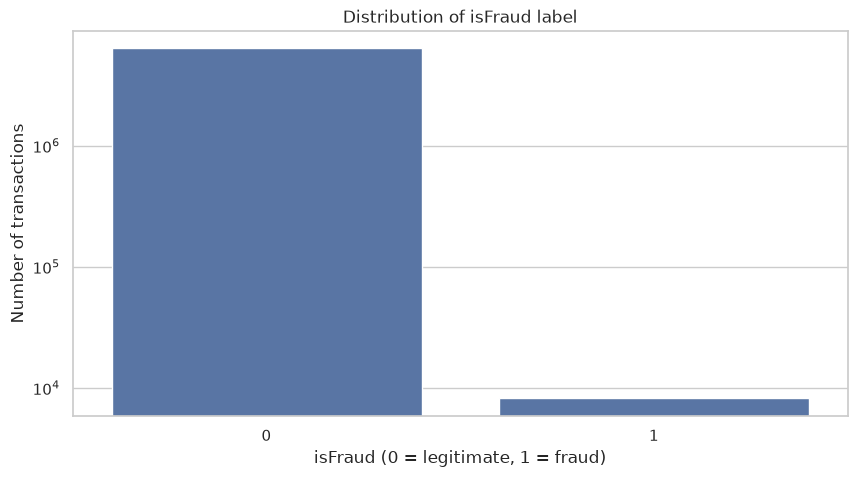

In [12]:
fraud_counts = df["isFraud"].value_counts()
fraud_pct = df["isFraud"].value_counts(normalize=True) * 100

summary = pd.DataFrame({"count": fraud_counts, "percent": fraud_pct.round(4)})
print(summary)
print(f"\nTỉ lệ gian lận: {fraud_pct[1]:.3f}%  ->  dữ liệu mất cân bằng nghiêm trọng")

ax = sns.countplot(data=df, x="isFraud")
ax.set(title="Distribution of isFraud label", xlabel="isFraud (0 = legitimate, 1 = fraud)", ylabel="Number of transactions")
ax.set_yscale("log")
plt.show()

### 2.3 Phân tích theo loại giao dịch

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


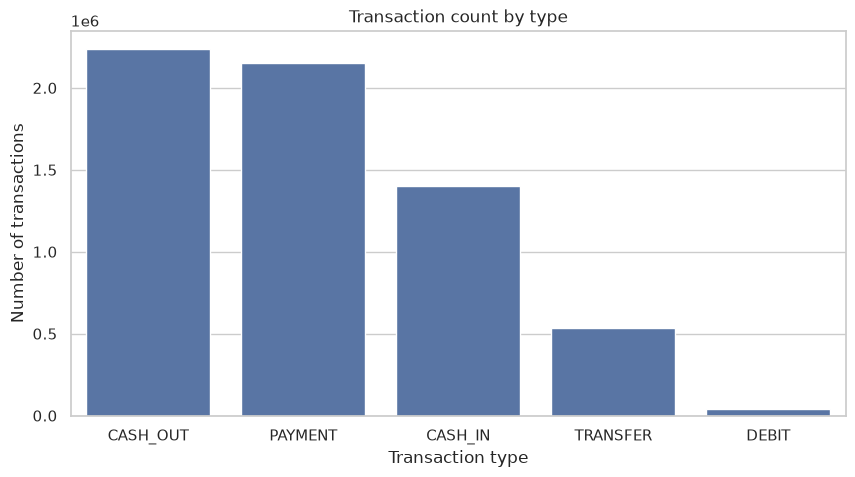

In [13]:
# Số lượng theo type
type_counts = df["type"].value_counts()
print(type_counts)

ax = sns.countplot(data=df, x="type", order=type_counts.index)
ax.set(title="Transaction count by type", xlabel="Transaction type", ylabel="Number of transactions")
plt.show()

          so_gian_lan  ti_le_gian_lan  tong_giao_dich
type                                                 
CASH_OUT         4116           0.184         2237500
TRANSFER         4097           0.769          532909
CASH_IN             0           0.000         1399284
DEBIT               0           0.000           41432
PAYMENT             0           0.000         2151495


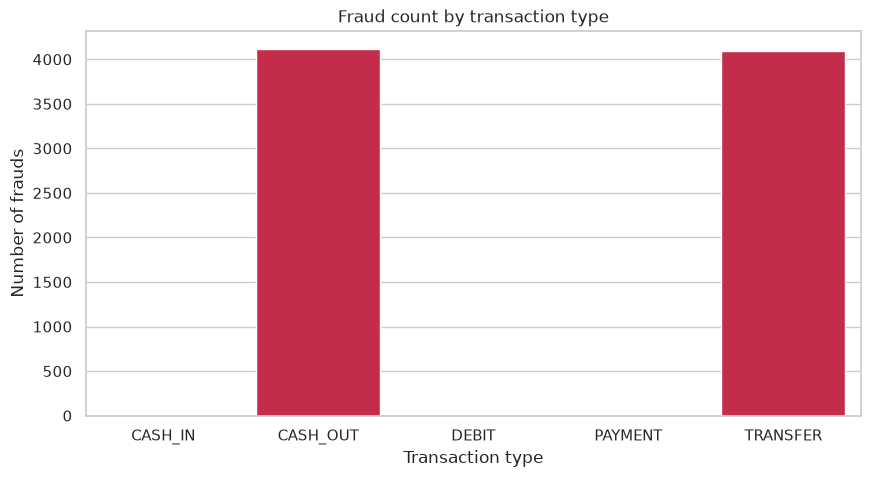

In [14]:
# Gian lận xảy ra ở loại giao dịch nào?
fraud_by_type = df.groupby("type", observed=True)["isFraud"].agg(["sum", "mean", "count"])
fraud_by_type.columns = ["so_gian_lan", "ti_le_gian_lan", "tong_giao_dich"]
fraud_by_type["ti_le_gian_lan"] = (fraud_by_type["ti_le_gian_lan"] * 100).round(3)
print(fraud_by_type.sort_values("so_gian_lan", ascending=False))

ax = sns.barplot(
    data=fraud_by_type.reset_index(),
    x="type", y="so_gian_lan", color="crimson",
)
ax.set(title="Fraud count by transaction type", xlabel="Transaction type", ylabel="Number of frauds")
plt.show()

### 2.3b Tỉ lệ gian lận theo kênh giao dịch

Ngoài **loại giao dịch** và **thời gian trong ngày**, ta so sánh tỉ lệ gian lận theo **kênh** (`channel`: web / mobile / POS / api) — một chiều ngữ cảnh riêng theo yêu cầu Module 2. `channel` là trường ngữ cảnh **chỉ dùng cho EDA**, không đưa vào mô hình.

> ⚠️ Lưu ý: giống các cờ rủi ro tổng hợp, `channel` được sinh **có điều kiện theo `isFraud`** (Module 1), nên chênh lệch tỉ lệ gian lận giữa các kênh là **do thiết kế mô phỏng**, không phải phát hiện từ dữ liệu thật.

           so_gd  so_gian_lan  ti_le_gian_lan
channel                                      
api       320093         1659          0.5183
web      2227044         3671          0.1648
POS       952246          824          0.0865
mobile   2863237         2059          0.0719


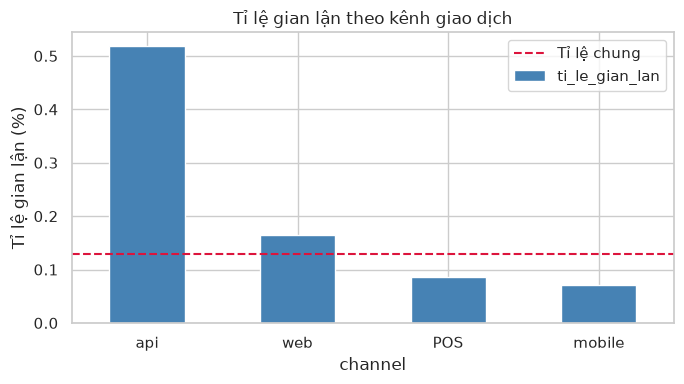

In [15]:
# --- 2.3b Tỉ lệ gian lận theo kênh giao dịch ---
ch_stat = (df.groupby("channel")["isFraud"]
             .agg(so_gd="count", so_gian_lan="sum")
             .assign(ti_le_gian_lan=lambda d: d["so_gian_lan"] / d["so_gd"] * 100)
             .sort_values("ti_le_gian_lan", ascending=False))
print(ch_stat.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
ch_stat["ti_le_gian_lan"].plot(kind="bar", color="steelblue", ax=ax)
ax.axhline(df["isFraud"].mean() * 100, color="crimson", ls="--", label="Tỉ lệ chung")
ax.set(title="Tỉ lệ gian lận theo kênh giao dịch", ylabel="Tỉ lệ gian lận (%)", xlabel="channel")
ax.legend(); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

> **Nhận xét:** Gian lận chỉ xảy ra ở hai loại `TRANSFER` và `CASH_OUT`. Đây là đặc trưng rất quan trọng cho mô hình phát hiện.

### 2.4 Phân tích số tiền giao dịch (amount)

Amount - giao dịch hợp lệ:


count    6.354407e+06
mean     1.781970e+05
std      5.962370e+05
min      1.000000e-02
25%      1.336840e+04
50%      7.468472e+04
75%      2.083648e+05
max      9.244552e+07
Name: amount, dtype: float64

Amount - giao dịch gian lận:
count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64


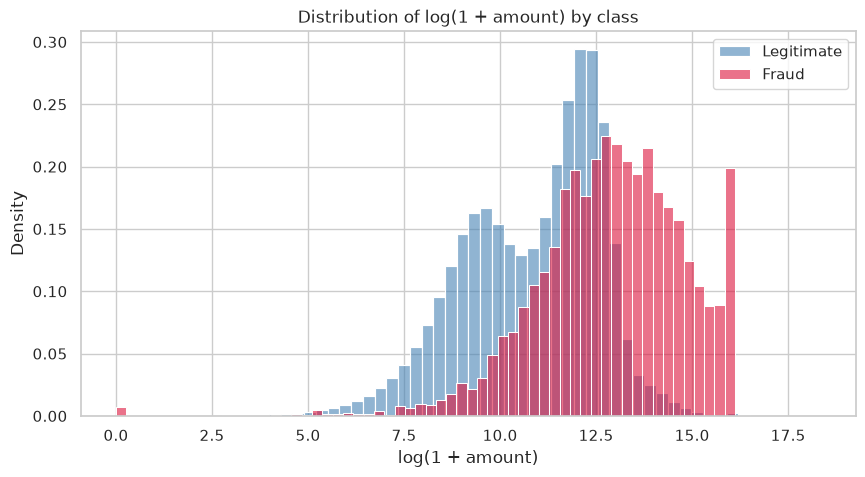

In [16]:
print("Amount - giao dịch hợp lệ:")
print(df.loc[df.isFraud == 0, "amount"].describe())
print("\nAmount - giao dịch gian lận:")
print(df.loc[df.isFraud == 1, "amount"].describe())

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(np.log1p(df.loc[df.isFraud == 0, "amount"]), bins=60, color="steelblue", label="Legitimate", stat="density", alpha=0.6, ax=ax)
sns.histplot(np.log1p(df.loc[df.isFraud == 1, "amount"]), bins=60, color="crimson", label="Fraud", stat="density", alpha=0.6, ax=ax)
ax.set(title="Distribution of log(1 + amount) by class", xlabel="log(1 + amount)", ylabel="Density")
ax.legend()
plt.show()

### 2.5 Đặc trưng số dư & lỗi số dư

Nhiều giao dịch gian lận rút sạch tài khoản nguồn. Ta tạo thêm đặc trưng sai lệch số dư để kiểm tra.

In [17]:
# Sai lệch số dư: nếu giao dịch chuẩn thì newbalance = oldbalance -/+ amount
df["errorBalanceOrig"] = df["newbalanceOrig"] + df["amount"] - df["oldbalanceOrg"]
df["errorBalanceDest"] = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]

print("Trung bình errorBalanceOrig theo nhãn:")
print(df.groupby("isFraud")["errorBalanceOrig"].mean())
print("\nTrung bình errorBalanceDest theo nhãn:")
print(df.groupby("isFraud")["errorBalanceDest"].mean())

Trung bình errorBalanceOrig theo nhãn:
isFraud
0    201338.558109
1     10692.325265
Name: errorBalanceOrig, dtype: float64

Trung bình errorBalanceDest theo nhãn:


isFraud
0     54692.231734
1    732509.301069
Name: errorBalanceDest, dtype: float64


In [18]:
# Tỉ lệ giao dịch làm cạn sạch số dư nguồn (newbalanceOrig == 0)
drained = df[df["newbalanceOrig"] == 0]
print(f"Tỉ lệ gian lận khi số dư nguồn về 0: {drained['isFraud'].mean()*100:.3f}%")
print(f"Tỉ lệ gian lận toàn bộ dataset:      {df['isFraud'].mean()*100:.3f}%")

Tỉ lệ gian lận khi số dư nguồn về 0: 0.223%
Tỉ lệ gian lận toàn bộ dataset:      0.129%


### 2.6 Cờ hệ thống isFlaggedFraud

In [19]:
print("Ma trận isFlaggedFraud vs isFraud:")
print(pd.crosstab(df["isFlaggedFraud"], df["isFraud"]))
print(f"\nHệ thống chỉ gắn cờ {df['isFlaggedFraud'].sum()} giao dịch trong khi có {df['isFraud'].sum():,} gian lận thực tế.")

Ma trận isFlaggedFraud vs isFraud:


isFraud               0     1
isFlaggedFraud               
0               6354407  8197
1                     0    16

Hệ thống chỉ gắn cờ 16 giao dịch trong khi có 8,213 gian lận thực tế.


### 2.7 Tương quan giữa các đặc trưng số

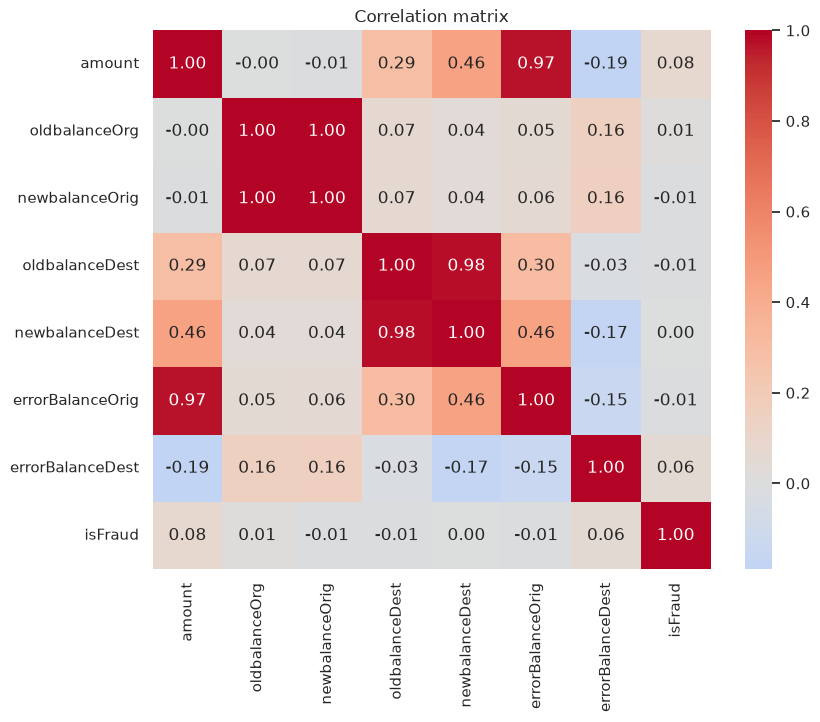

In [20]:
num_cols = [
    "amount", "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest",
    "errorBalanceOrig", "errorBalanceDest", "isFraud",
]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix")
plt.show()

### 2.8 Mẫu gian lận theo tín hiệu tổng hợp (thời gian & bất khớp)

Trực quan hoá quan hệ giữa **các đặc trưng tổng hợp (nguồn 2)** và nhãn gian lận — phần EDA rubric nêu đích danh (*time windows*, *geographic mismatch patterns*).

> ⚠️ **Lưu ý:** các cờ nhị phân (`is_new_device`, `*_mismatch`), `account_age_days`, `ip_billing_distance_km` được **sinh có điều kiện theo `isFraud`** (Module 1) nên tách biệt rõ *do thiết kế* — đây là lý do ta so sánh Base vs Full và bàn kỹ ở **mục 5.3**. Riêng `hour_of_day` suy từ `step` nên phản ánh **mẫu thời gian THỰC** của PaySim, không bị rò rỉ.

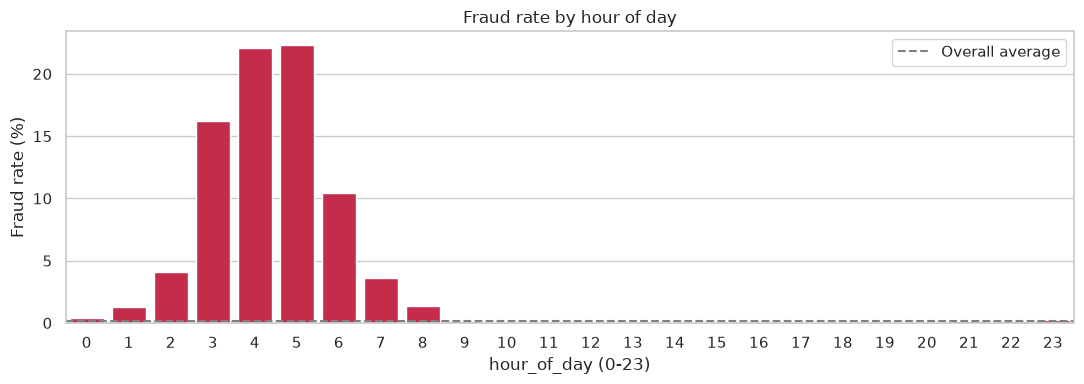

In [21]:
# Tỉ lệ gian lận theo giờ trong ngày (hour_of_day suy từ step -> mẫu thời gian thực)
fr_hour = df.groupby("hour_of_day")["isFraud"].mean() * 100

fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(x=fr_hour.index, y=fr_hour.values, color="crimson", ax=ax)
ax.axhline(df["isFraud"].mean() * 100, color="gray", linestyle="--", label="Overall average")
ax.set(title="Fraud rate by hour of day", xlabel="hour_of_day (0-23)", ylabel="Fraud rate (%)")
ax.legend()
plt.tight_layout()
plt.show()

                           Flag = 0  Flag = 1
Flag                                         
is_new_device                 0.063     0.879
shipping_billing_mismatch     0.079     1.716
ip_billing_mismatch           0.066     3.131


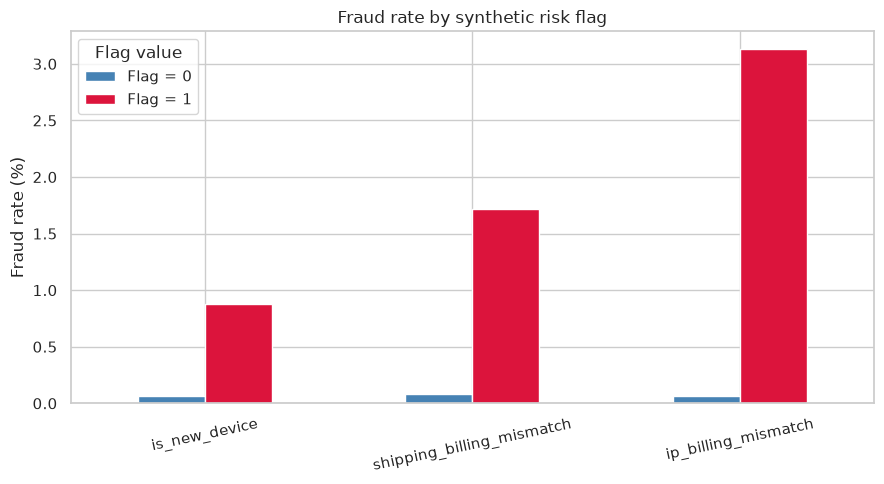

In [22]:
# Tỉ lệ gian lận theo các cờ rủi ro nhị phân (bất khớp địa lý / thiết bị lạ)
flags = ["is_new_device", "shipping_billing_mismatch", "ip_billing_mismatch"]
rows = []
for f in flags:
    g = df.groupby(f)["isFraud"].mean() * 100
    rows.append({"Flag": f, "Flag = 0": g.get(0, 0.0), "Flag = 1": g.get(1, 0.0)})
flag_df = pd.DataFrame(rows).set_index("Flag")
print(flag_df.round(3))

ax = flag_df.plot(kind="bar", figsize=(9, 5), color=["steelblue", "crimson"])
ax.set(title="Fraud rate by synthetic risk flag", ylabel="Fraud rate (%)", xlabel="")
ax.legend(title="Flag value")
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()

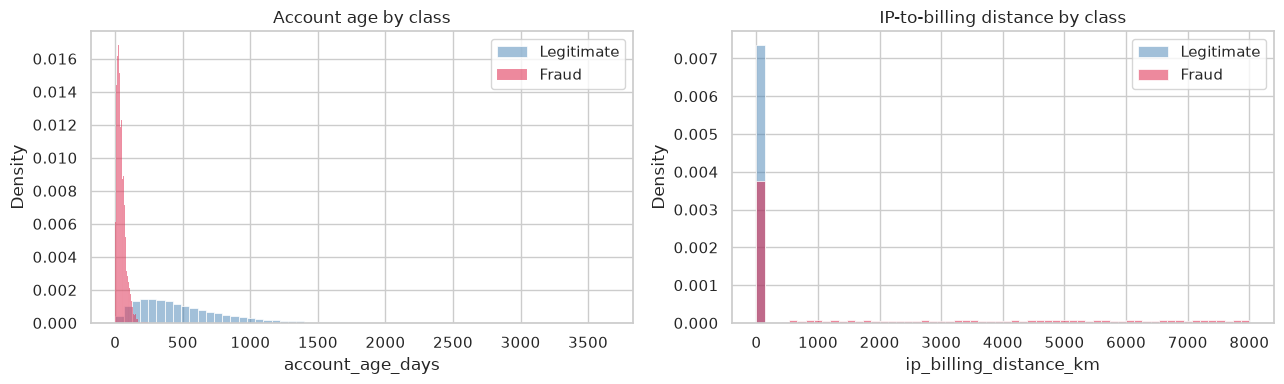

In [23]:
# Phân bố đặc trưng liên tục theo nhãn: tuổi tài khoản & khoảng cách IP->billing
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for lbl, color, ten in [(0, "steelblue", "Legitimate"), (1, "crimson", "Fraud")]:
    sub = df[df["isFraud"] == lbl]
    sns.histplot(sub["account_age_days"], bins=60, stat="density", color=color,
                 alpha=0.5, label=ten, ax=axes[0])
    sns.histplot(sub["ip_billing_distance_km"], bins=60, stat="density", color=color,
                 alpha=0.5, label=ten, ax=axes[1])
axes[0].set(title="Account age by class", xlabel="account_age_days", ylabel="Density")
axes[1].set(title="IP-to-billing distance by class", xlabel="ip_billing_distance_km", ylabel="Density")
axes[0].legend(); axes[1].legend()
plt.tight_layout()
plt.show()

### 2.9 Tổng kết nhận định cho bài toán phát hiện gian lận

- **Mất cân bằng lớp nghiêm trọng** (~0.13% gian lận) → cần dùng các kỹ thuật như class weighting, SMOTE, hoặc metric phù hợp (Precision/Recall, PR-AUC) thay vì Accuracy.
- **Gian lận chỉ ở `TRANSFER` và `CASH_OUT`** → có thể lọc trước theo loại giao dịch.
- **Đặc trưng số dư (errorBalanceOrig/Dest)** phân biệt tốt gian lận và hợp lệ → nên đưa vào mô hình.
- **`isFlaggedFraud` gần như vô dụng** (bắt được rất ít) → không nên tin cậy làm nhãn.
- **`nameOrig`/`nameDest`** là ID → nên bỏ hoặc chỉ dùng để tạo đặc trưng tần suất, tránh leakage.
- **Đặc trưng tổng hợp** (`account_age_days`, `is_new_device`, `failed_payment_attempts`, `ip_billing_distance_km`...) tách biệt rõ giữa hai nhãn (mục 2.8) → là risk-signal tốt, nhưng do được sinh từ nhãn nên cần đánh giá thận trọng qua so sánh Base vs Full (mục 5.3).

Các bước tiếp theo: feature engineering, train mô hình (Logistic Regression / Random Forest / XGBoost) với xử lý mất cân bằng và đánh giá bằng PR-AUC.

## Module 3 — Data Cleaning

Làm sạch dữ liệu **sau EDA**, ghi lại mọi quyết định kèm so sánh *before/after*. PaySim là dữ liệu mô phỏng nên chất lượng vốn cao → trọng tâm là **kiểm chứng có hệ thống** và **giải trình quyết định** (đặc biệt việc *không* cắt outlier `amount`), thay vì sửa đổi ồ ạt.

Các bước:
1. Missing values & bản ghi trùng
2. Giá trị bất hợp lý (số tiền ≤ 0, số dư âm)
3. Outlier `amount` — phân tích & quyết định
4. Đặc thù số dư tài khoản merchant
5. Tổng hợp before/after + bảng quyết định

> Nguyên tắc: mỗi lần xoá dòng đều **đếm số gian lận bị xoá kèm theo** để chắc chắn không vô tình đánh mất nhãn dương hiếm hoi.

In [24]:
# Ghi nhận trạng thái TRƯỚC khi làm sạch + sổ nhật ký các bước
rows_raw = len(df)
fraud_raw = int(df["isFraud"].sum())
clean_log = []

def ghi_nhat_ky(ten_buoc, mask_xoa):
    """Ghi số dòng & số gian lận bị xoá cho một bước làm sạch."""
    clean_log.append({
        "buoc": ten_buoc,
        "so_dong_xoa": int(mask_xoa.sum()),
        "gian_lan_xoa": int(df.loc[mask_xoa, "isFraud"].sum()),
    })

print(f"TRƯỚC làm sạch: {rows_raw:,} dòng | {fraud_raw:,} gian lận ({fraud_raw/rows_raw*100:.3f}%)")

# --- 3.1a Missing values ---
missing = df.isna().sum()
print("\nSố giá trị thiếu theo cột (chỉ hiện cột > 0):")
print(missing[missing > 0] if (missing > 0).any() else "  -> Không có giá trị thiếu.")

TRƯỚC làm sạch: 6,362,620 dòng | 8,213 gian lận (0.129%)



Số giá trị thiếu theo cột (chỉ hiện cột > 0):
  -> Không có giá trị thiếu.


In [25]:
# --- 3.1b Bản ghi trùng ---
# Kiểm tra trùng trên các cột GIAO DỊCH GỐC của PaySim; các trường tổng hợp là ngẫu nhiên
# theo từng dòng nên nếu tính cả chúng sẽ không bao giờ thấy trùng.
core_cols = [
    "step", "type", "amount", "nameOrig",
    "oldbalanceOrg", "newbalanceOrig", "nameDest",
    "oldbalanceDest", "newbalanceDest", "isFraud",
]
dup_mask = df.duplicated(subset=core_cols, keep="first")
print(f"Số bản ghi trùng (theo cột gốc): {int(dup_mask.sum()):,}")

ghi_nhat_ky("Bản ghi trùng", dup_mask)
df = df[~dup_mask].copy()
print(f"-> Còn lại: {len(df):,} dòng.")

Số bản ghi trùng (theo cột gốc): 0


-> Còn lại: 6,362,620 dòng.


### 3.2 Giá trị bất hợp lý

Kiểm tra các giá trị vi phạm ràng buộc nghiệp vụ: số tiền phải > 0, số dư không được âm.

In [26]:
# Số tiền <= 0 và số dư âm là bất hợp lý
invalid_amount = df["amount"] <= 0
neg_balance = (
    (df["oldbalanceOrg"] < 0) | (df["newbalanceOrig"] < 0) |
    (df["oldbalanceDest"] < 0) | (df["newbalanceDest"] < 0)
)
print(f"Giao dịch amount <= 0 : {int(invalid_amount.sum()):,} "
      f"(gian lận: {int(df.loc[invalid_amount, 'isFraud'].sum())})")
print(f"Giao dịch số dư âm    : {int(neg_balance.sum()):,}")

invalid_mask = invalid_amount | neg_balance
ghi_nhat_ky("Giá trị bất hợp lý (amount<=0 / số dư âm)", invalid_mask)
df = df[~invalid_mask].copy()
print(f"-> Còn lại: {len(df):,} dòng.")

Giao dịch amount <= 0 : 16 (gian lận: 16)
Giao dịch số dư âm    : 0


-> Còn lại: 6,362,604 dòng.


### 3.2b Nhất quán danh mục & dấu thời gian hợp lệ

Ngoài giá trị bất hợp lý, ta kiểm chứng thêm **tính nhất quán của biến phân loại** và **dấu thời gian**:
- `type` phải thuộc 5 giá trị hợp lệ của PaySim; chuẩn hoá khoảng trắng/chữ hoa để tránh danh mục "ẩn".
- Tiền tố tài khoản đúng quy ước (`nameOrig` = `C…`, `nameDest` = `C…`/`M…`).
- `step` (mốc giờ) trong khoảng hợp lý và `hour_of_day` ∈ [0, 23].

PaySim là dữ liệu mô phỏng nên kỳ vọng **0 vi phạm** — nhưng đây là bước kiểm chứng bắt buộc, có ghi nhật ký before/after như mọi bước làm sạch khác.

In [27]:
# --- 3.2b Nhất quán danh mục & dấu thời gian hợp lệ ---
# (a) Chuẩn hoá & kiểm tra giá trị hợp lệ của `type`
df["type"] = df["type"].astype(str).str.strip().str.upper()
VALID_TYPES = {"PAYMENT", "TRANSFER", "CASH_OUT", "DEBIT", "CASH_IN"}
bad_type = ~df["type"].isin(VALID_TYPES)
print(f"type ngoài danh mục hợp lệ : {int(bad_type.sum()):,}")
print("Phân bố type:", df["type"].value_counts().to_dict())

# (b) Nhất quán tiền tố tài khoản (PaySim: nameOrig='C...', nameDest='C...'/'M...')
bad_orig = ~df["nameOrig"].astype(str).str.startswith("C")
bad_dest = ~df["nameDest"].astype(str).str.match(r"^[CM]")
print(f"nameOrig sai tiền tố (khác 'C')     : {int(bad_orig.sum()):,}")
print(f"nameDest sai tiền tố (khác 'C'/'M') : {int(bad_dest.sum()):,}")

# (c) Dấu thời gian hợp lệ: step ∈ [1, 744] (PaySim ~30 ngày), hour_of_day ∈ [0, 23]
bad_step = (df["step"] < 1) | (df["step"] > 744)
bad_hour = (df["hour_of_day"] < 0) | (df["hour_of_day"] > 23)
print(f"step ngoài [1,744]      : {int(bad_step.sum()):,}")
print(f"hour_of_day ngoài [0,23]: {int(bad_hour.sum()):,}")

# Xoá bản ghi danh mục/thời gian bất hợp lệ (nếu có) + ghi nhật ký before/after
cat_time_bad = bad_type | bad_step | bad_hour
ghi_nhat_ky("Danh mục/thời gian bất hợp lệ (type/step/hour_of_day)", cat_time_bad)
_before = len(df)
df = df[~cat_time_bad].copy()
print(f"Đã xoá {_before - len(df):,} bản ghi bất hợp lệ → còn {len(df):,} dòng")

type ngoài danh mục hợp lệ : 0
Phân bố type: {'CASH_OUT': 2237484, 'PAYMENT': 2151495, 'CASH_IN': 1399284, 'TRANSFER': 532909, 'DEBIT': 41432}


nameOrig sai tiền tố (khác 'C')     : 0
nameDest sai tiền tố (khác 'C'/'M') : 0
step ngoài [1,744]      : 0
hour_of_day ngoài [0,23]: 0


Đã xoá 0 bản ghi bất hợp lệ → còn 6,362,604 dòng


### 3.3 Outlier số tiền `amount` — phân tích & quyết định

`amount` lệch phải mạnh, đuôi rất dài. Ta **không cắt outlier một cách máy móc** vì gian lận thường nằm ở chính các giao dịch giá trị lớn — cắt đuôi = xoá mất nhãn dương. Chứng minh bằng số liệu trước khi quyết định.

In [28]:
# Ngưỡng IQR (quy tắc 1.5*IQR) trên amount
q1, q3 = df["amount"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
outlier_mask = df["amount"] > upper_fence

n_out = int(outlier_mask.sum())
fr_out = df.loc[outlier_mask, "isFraud"].mean() * 100
fr_all = df["isFraud"].mean() * 100
print(f"Ngưỡng trên (Q3 + 1.5*IQR): {upper_fence:,.0f}")
print(f"Số 'outlier' amount: {n_out:,} ({n_out/len(df)*100:.2f}% dữ liệu)")
print(f"Tỉ lệ gian lận TRONG nhóm outlier: {fr_out:.3f}%")
print(f"Tỉ lệ gian lận toàn bộ:            {fr_all:.3f}%")
print("\n-> QUYẾT ĐỊNH: GIỮ nguyên. Nhóm giá trị lớn có mật độ gian lận cao hơn hẳn;")
print("   cắt bỏ sẽ xoá mất nhãn dương hiếm. 'Outlier' ở đây là TÍN HIỆU, không phải nhiễu.")

# Không xoá — ghi nhật ký 0 dòng để minh bạch
ghi_nhat_ky("Outlier amount (GIỮ, không cắt)", pd.Series(False, index=df.index))

Ngưỡng trên (Q3 + 1.5*IQR): 501,720
Số 'outlier' amount: 338,077 (5.31% dữ liệu)
Tỉ lệ gian lận TRONG nhóm outlier: 1.140%
Tỉ lệ gian lận toàn bộ:            0.129%

-> QUYẾT ĐỊNH: GIỮ nguyên. Nhóm giá trị lớn có mật độ gian lận cao hơn hẳn;
   cắt bỏ sẽ xoá mất nhãn dương hiếm. 'Outlier' ở đây là TÍN HIỆU, không phải nhiễu.


### 3.4 Đặc thù số dư tài khoản merchant

Trong PaySim, tài khoản đích là **merchant** (`nameDest` bắt đầu bằng `M`) không được cập nhật số dư (`oldbalanceDest = newbalanceDest = 0`). Đây là **đặc điểm thiết kế của dữ liệu**, không phải lỗi cần sửa — nhưng phải ghi nhận vì nó giải thích vì sao `errorBalanceDest` lệch ở nhóm này.

In [29]:
dest_merchant = df["nameDest"].str.startswith("M")
merchant_zero = ((df.loc[dest_merchant, "oldbalanceDest"] == 0) &
                 (df.loc[dest_merchant, "newbalanceDest"] == 0)).mean() * 100
print(f"Tỉ lệ giao dịch có đích là merchant (M...): {dest_merchant.mean()*100:.2f}%")
print(f"Trong đó số dư đích = 0 hoàn toàn:          {merchant_zero:.2f}%")
print(f"\nSố giao dịch gian lận có đích là merchant: {int(df.loc[dest_merchant, 'isFraud'].sum())}")
print("-> Gian lận chỉ nhắm tài khoản khách (C...), không phải merchant -> khớp bản chất PaySim.")
print("-> GIỮ nguyên; errorBalanceDest ở nhóm merchant phản ánh đặc thù dữ liệu, không xoá.")

Tỉ lệ giao dịch có đích là merchant (M...): 33.81%
Trong đó số dư đích = 0 hoàn toàn:          100.00%

Số giao dịch gian lận có đích là merchant: 0
-> Gian lận chỉ nhắm tài khoản khách (C...), không phải merchant -> khớp bản chất PaySim.
-> GIỮ nguyên; errorBalanceDest ở nhóm merchant phản ánh đặc thù dữ liệu, không xoá.


In [30]:
# --- 3.5 Tổng hợp before/after ---
log_df = pd.DataFrame(clean_log)
log_df["so_dong_xoa_luy_ke"] = log_df["so_dong_xoa"].cumsum()
print("Nhật ký làm sạch theo bước:")
print(log_df.to_string(index=False))

rows_after = len(df)
fraud_after = int(df["isFraud"].sum())
print(f"\nTRƯỚC:  {rows_raw:,} dòng | {fraud_raw:,} gian lận")
print(f"SAU:    {rows_after:,} dòng | {fraud_after:,} gian lận")
print(f"Đã xoá: {rows_raw - rows_after:,} dòng ({(rows_raw-rows_after)/rows_raw*100:.4f}%) "
      f"| gian lận mất: {fraud_raw - fraud_after}")

# Kiểm chứng tính nhất quán của nhật ký
assert (rows_raw - rows_after) == int(log_df["so_dong_xoa"].sum()), "Số dòng xoá không khớp nhật ký!"
assert (fraud_raw - fraud_after) == int(log_df["gian_lan_xoa"].sum()), "Số gian lận xoá không khớp nhật ký!"
print("\n✔ df đã sạch & nhất quán, sẵn sàng cho Module 4.")

Nhật ký làm sạch theo bước:
                                                 buoc  so_dong_xoa  gian_lan_xoa  so_dong_xoa_luy_ke
                                        Bản ghi trùng            0             0                   0
            Giá trị bất hợp lý (amount<=0 / số dư âm)           16            16                  16
Danh mục/thời gian bất hợp lệ (type/step/hour_of_day)            0             0                  16
                      Outlier amount (GIỮ, không cắt)            0             0                  16

TRƯỚC:  6,362,620 dòng | 8,213 gian lận
SAU:    6,362,604 dòng | 8,197 gian lận
Đã xoá: 16 dòng (0.0003%) | gian lận mất: 16

✔ df đã sạch & nhất quán, sẵn sàng cho Module 4.


### 3.6 Bảng quyết định làm sạch

| Vấn đề | Quyết định | Lý do |
|--------|-----------|-------|
| Missing values | Không xử lý (nếu = 0) | PaySim mô phỏng, không thiếu dữ liệu |
| Bản ghi trùng | Xoá nếu có (giữ bản đầu) | Trùng giao dịch gốc là lỗi ghi nhận |
| `amount ≤ 0` / số dư âm | Xoá | Vi phạm ràng buộc nghiệp vụ |
| Outlier `amount` | **GIỮ** | Giá trị lớn là *tín hiệu* gian lận, không phải nhiễu |
| Số dư merchant = 0 | **GIỮ** | Đặc thù thiết kế PaySim, không phải lỗi |

> Mọi thay đổi được kiểm chứng: số dòng và số gian lận before/after khớp với nhật ký (mục 3.5, có `assert`).

## Module 4 — Feature Engineering & chuẩn bị dữ liệu

Dựa trên EDA:
- **Lọc chỉ `TRANSFER` và `CASH_OUT`** (gian lận chỉ xảy ra ở 2 loại này) → giảm nhiễu, tăng mật độ nhãn dương.
- Giữ các đặc trưng số dư gốc và `errorBalance*` vì phân biệt tốt.
- Bỏ `nameOrig`/`nameDest` (ID → tránh leakage) và `isFlaggedFraud` (vô dụng).
- Mã hoá `type` bằng biến nhị phân `type_TRANSFER`.

**Kết hợp 2 nguồn dữ liệu (yêu cầu cốt lõi của đồ án).** Ta xây dựng *hai* không gian đặc trưng để đo đúng đóng góp của dữ liệu tổng hợp:

| Bộ đặc trưng | Thành phần |
|--------------|------------|
| **Base** | PaySim gốc + risk-signal thật (velocity, time-since-last) (nguồn 1) |
| **Full** | PaySim + 7 tín hiệu rủi ro tổng hợp Faker (nguồn 2) |

> ⚠️ **Lưu ý về rò rỉ nhãn (label leakage).** Các tín hiệu tổng hợp (`is_new_device`, `shipping_billing_mismatch`, …) được **sinh có điều kiện theo `isFraud`** ở Module 1, nên sức mạnh dự báo của chúng một phần là *do thiết kế* chứ không phải *phát hiện được từ dữ liệu thực*. Vì vậy ta không nhét chúng vào một cách vô tư mà **so sánh Base vs Full** để lượng hoá mức tăng, đồng thời nêu rõ giới hạn khi diễn giải (mục 5.3). Các trường ID nhiều mức (`home_country`, `device_fingerprint`) được bỏ vì cần mã hoá riêng và `is_new_device` đã tóm tắt tín hiệu thiết bị.

### 4.1 Đặc trưng risk-signal thật từ chuỗi giao dịch

Đề bài yêu cầu *velocity per account* và *time-since-last-purchase*. Khác với tín hiệu tổng hợp (sinh từ nhãn), hai đặc trưng này **suy từ chính lịch sử giao dịch PaySim** nên **không rò rỉ nhãn** — được xếp vào bộ **Base**.
- `txn_count_acct`: số giao dịch luỹ kế của tài khoản tính đến hiện tại (nhân quả).
- `time_since_last_txn`: số giờ kể từ giao dịch liền trước của cùng tài khoản (`-1` nếu là giao dịch đầu).

In [31]:
# Sắp theo (tài khoản, thời gian) rồi tính đặc trưng nhân quả cho từng tài khoản
df = df.sort_values(["nameOrig", "step"]).reset_index(drop=True)
g = df.groupby("nameOrig", observed=True)
df["txn_count_acct"] = (g.cumcount() + 1).astype("int32")            # velocity luỹ kế
df["time_since_last_txn"] = g["step"].diff().fillna(-1).astype("int32")  # -1 = giao dịch đầu

print("Đã tạo txn_count_acct & time_since_last_txn.")
print(df[["txn_count_acct", "time_since_last_txn"]].describe().round(2))

Đã tạo txn_count_acct & time_since_last_txn.


       txn_count_acct  time_since_last_txn
count      6362604.00           6362604.00
mean             1.00                -0.77
std              0.04                 7.71
min              1.00                -1.00
25%              1.00                -1.00
50%              1.00                -1.00
75%              1.00                -1.00
max              3.00               704.00


In [32]:
# Lọc chỉ 2 loại giao dịch có gian lận
model_df = df[df["type"].isin(["TRANSFER", "CASH_OUT"])].copy()

# Mã hoá loại giao dịch: 1 = TRANSFER, 0 = CASH_OUT
model_df["type_TRANSFER"] = (model_df["type"] == "TRANSFER").astype("int8")

# --- Bộ BASE: đặc trưng giao dịch gốc từ PaySim (nguồn 1) ---
base_cols = [
    "step",
    "amount",
    "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest",
    "errorBalanceOrig", "errorBalanceDest",
    "type_TRANSFER",
    "txn_count_acct", "time_since_last_txn",
]

# --- Tín hiệu rủi ro tổng hợp từ Faker (nguồn 2) ---
# Chỉ giữ trường số/nhị phân quan sát được tại thời điểm chấm giao dịch.
syn_cols = [
    "account_age_days",
    "hour_of_day",
    "shipping_billing_mismatch",
    "is_new_device",
    "failed_payment_attempts",
    "ip_billing_mismatch",
    "ip_billing_distance_km",
]

# --- Bộ FULL: kết hợp cả hai nguồn ---
full_cols = base_cols + syn_cols

X = model_df[full_cols]
y = model_df["isFraud"]

print(f"Số mẫu sau khi lọc: {len(model_df):,}")
print(f"Số gian lận: {y.sum():,}  ({y.mean()*100:.3f}%)")
print(f"Base (PaySim): {len(base_cols)}  |  Tổng hợp: {len(syn_cols)}  |  Full: {len(full_cols)}")
X.head()

Số mẫu sau khi lọc: 2,770,393
Số gian lận: 8,197  (0.296%)
Base (PaySim): 11  |  Tổng hợp: 7  |  Full: 18


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,errorBalanceOrig,errorBalanceDest,type_TRANSFER,txn_count_acct,time_since_last_txn,account_age_days,hour_of_day,shipping_billing_mismatch,is_new_device,failed_payment_attempts,ip_billing_mismatch,ip_billing_distance_km
0,249,244486.46,8946.00,0.00,526950.37,771436.84,235540.46,-0.01,0,1,-1,145,9,0,0,0,0,1.6
6,327,211189.64,0.00,0.00,2609840.34,2821029.98,211189.64,0.00,0,1,-1,807,15,0,0,1,0,51.8
7,41,93865.13,351422.72,257557.59,178083.14,271948.26,0.00,0.01,0,1,-1,784,17,0,0,0,0,6.6
8,226,3228390.11,24996.00,0.00,878327.64,4106717.75,3203394.11,0.00,1,1,-1,237,10,0,0,1,0,64.8
9,185,233109.79,20623.00,0.00,0.00,233109.79,212486.79,0.00,0,1,-1,216,17,0,0,0,0,7.3


In [33]:
from sklearn.model_selection import train_test_split

# Chia train/test phân tầng theo nhãn (chia MỘT lần, dùng chung cho cả 2 bộ đặc trưng)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Hai không gian đặc trưng chỉ khác nhau ở tập cột → cùng một lần chia
X_train_base, X_test_base = X_train[base_cols], X_test[base_cols]
X_train_full, X_test_full = X_train[full_cols], X_test[full_cols]

print(f"Train: {X_train.shape[0]:,} mẫu | gian lận = {y_train.sum():,} ({y_train.mean()*100:.3f}%)")
print(f"Test:  {X_test.shape[0]:,} mẫu | gian lận = {y_test.sum():,} ({y_test.mean()*100:.3f}%)")

Train: 1,939,275 mẫu | gian lận = 5,738 (0.296%)
Test:  831,118 mẫu | gian lận = 2,459 (0.296%)


### 4.2 Feature selection

Xếp hạng đặc trưng bằng **mutual information** (trên mẫu con để nhanh), độc lập với thuật toán cuối, rồi ra quyết định giữ/bỏ có ghi chép.

In [34]:
from sklearn.feature_selection import mutual_info_classif

# Mẫu con để tính MI nhanh (index đồng bộ với y_train)
samp = X_train_full.sample(n=min(50_000, len(X_train_full)), random_state=42)
mi = mutual_info_classif(samp, y_train.loc[samp.index], random_state=42)
mi_rank = pd.Series(mi, index=full_cols).sort_values(ascending=False)
print("Mutual information với nhãn (giảm dần):")
print(mi_rank.round(4))

weak = mi_rank[mi_rank < 0.0005].index.tolist()
print(f"\nĐặc trưng gần như vô thông tin (MI < 5e-4): {weak}")
print("-> QUYẾT ĐỊNH: giữ toàn bộ cho mô hình cây (không gây hại), nhưng ghi nhận nhóm yếu")
print("   để có thể tinh giản nếu cần mô hình gọn/nhanh hơn cho triển khai.")

Mutual information với nhãn (giảm dần):
failed_payment_attempts      0.0104
txn_count_acct               0.0093
account_age_days             0.0084
oldbalanceOrg                0.0081
errorBalanceOrig             0.0069
newbalanceDest               0.0052
hour_of_day                  0.0051
step                         0.0044
ip_billing_mismatch          0.0041
errorBalanceDest             0.0040
ip_billing_distance_km       0.0040
is_new_device                0.0022
amount                       0.0020
oldbalanceDest               0.0020
shipping_billing_mismatch    0.0020
type_TRANSFER                0.0014
time_since_last_txn          0.0007
newbalanceOrig               0.0000
dtype: float64

Đặc trưng gần như vô thông tin (MI < 5e-4): ['newbalanceOrig']
-> QUYẾT ĐỊNH: giữ toàn bộ cho mô hình cây (không gây hại), nhưng ghi nhận nhóm yếu
   để có thể tinh giản nếu cần mô hình gọn/nhanh hơn cho triển khai.


## Module 5 — Phát triển & Đánh giá mô hình

### 5.1 Huấn luyện mô hình

Mỗi thuật toán được huấn luyện trên **cả hai** bộ đặc trưng (Base = chỉ PaySim, Full = PaySim + tín hiệu tổng hợp) để đo đóng góp của nguồn 2:
- **Logistic Regression** (`class_weight="balanced"`) — baseline tuyến tính, có chuẩn hoá.
- **Random Forest** (`class_weight="balanced_subsample"`) — cây ensemble bagging.
- **XGBoost** (`scale_pos_weight`) — bắt tín hiệu phi tuyến.

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def build_logreg():
    # StandardScaler vì thang đo amount/balance/khoảng cách rất lớn
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1),
    )

logreg_base = build_logreg().fit(X_train_base, y_train)
logreg_full = build_logreg().fit(X_train_full, y_train)
print("Đã huấn luyện Logistic Regression (Base & Full).")

/mnt/storage/bioinformatics-data/namle/test/905-fraud-detection/repo/.pixi/envs/default/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/mnt/storage/bioinformatics-data/namle/test/905-fraud-detection/repo/.pixi/envs/default/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Đã huấn luyện Logistic Regression (Base & Full).


In [36]:
from xgboost import XGBClassifier

# scale_pos_weight = số mẫu âm / số mẫu dương để bù mất cân bằng
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.1f}")

def build_xgb():
    return XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr",
        n_jobs=-1,
        random_state=42,
    )

xgb_base = build_xgb().fit(X_train_base, y_train)
xgb_full = build_xgb().fit(X_train_full, y_train)
print("Đã huấn luyện XGBoost (Base & Full).")

scale_pos_weight = 337.0


Đã huấn luyện XGBoost (Base & Full).


In [37]:
from sklearn.ensemble import RandomForestClassifier

def build_rf():
    return RandomForestClassifier(
        n_estimators=100, max_depth=16, min_samples_leaf=5,
        max_samples=0.5, class_weight="balanced_subsample",
        n_jobs=-1, random_state=42,
    )

rf_base = build_rf().fit(X_train_base, y_train)
rf_full = build_rf().fit(X_train_full, y_train)
print("Đã huấn luyện Random Forest (Base & Full).")

Đã huấn luyện Random Forest (Base & Full).


### 5.2 Đánh giá mô hình

Với dữ liệu mất cân bằng, ưu tiên **PR-AUC (Average Precision)**, **Recall** và **F1** thay vì Accuracy.

In [38]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, roc_auc_score,
    precision_recall_curve,
)

def danh_gia(model, ten_mo_hinh, X_eval):
    proba = model.predict_proba(X_eval)[:, 1]
    pred = (proba >= 0.5).astype(int)

    pr_auc = average_precision_score(y_test, proba)
    roc_auc = roc_auc_score(y_test, proba)

    print(f"===== {ten_mo_hinh} =====")
    print(f"PR-AUC (Average Precision): {pr_auc:.4f}")
    print(f"ROC-AUC:                    {roc_auc:.4f}\n")
    print(classification_report(y_test, pred, digits=4, target_names=["Hợp lệ", "Gian lận"]))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, pred))
    print()
    return {"ten": ten_mo_hinh, "proba": proba, "pr_auc": pr_auc, "roc_auc": roc_auc}

ket_qua = [
    danh_gia(logreg_base, "LogReg · Base",       X_test_base),
    danh_gia(logreg_full, "LogReg · Full",       X_test_full),
    danh_gia(rf_base,     "RandomForest · Base", X_test_base),
    danh_gia(rf_full,     "RandomForest · Full", X_test_full),
    danh_gia(xgb_base,    "XGBoost · Base",      X_test_base),
    danh_gia(xgb_full,    "XGBoost · Full",      X_test_full),
]

# Bảng tổng hợp so sánh
bang_ss = pd.DataFrame(
    [{"Mô hình": k["ten"], "PR-AUC": k["pr_auc"], "ROC-AUC": k["roc_auc"]} for k in ket_qua]
).set_index("Mô hình").round(4)
print("So sánh tổng hợp:")
print(bang_ss)

===== LogReg · Base =====
PR-AUC (Average Precision): 0.5932
ROC-AUC:                    0.9782



              precision    recall  f1-score   support

      Hợp lệ     0.9997    0.9405    0.9692    828659
    Gian lận     0.0433    0.9081    0.0827      2459

    accuracy                         0.9404    831118
   macro avg     0.5215    0.9243    0.5260    831118
weighted avg     0.9969    0.9404    0.9666    831118

Confusion matrix:
[[779372  49287]
 [   226   2233]]



===== LogReg · Full =====
PR-AUC (Average Precision): 0.9704
ROC-AUC:                    0.9999



              precision    recall  f1-score   support

      Hợp lệ     1.0000    0.9941    0.9971    828659
    Gian lận     0.3348    0.9947    0.5010      2459

    accuracy                         0.9941    831118
   macro avg     0.6674    0.9944    0.7490    831118
weighted avg     0.9980    0.9941    0.9956    831118

Confusion matrix:
[[823799   4860]
 [    13   2446]]



===== RandomForest · Base =====
PR-AUC (Average Precision): 0.9976
ROC-AUC:                    0.9989



...

              precision    recall  f1-score   support

      Hợp lệ     1.0000    1.0000    1.0000    828659
    Gian lận     1.0000    0.9963    0.9982      2459

    accuracy                         1.0000    831118
   macro avg     1.0000    0.9982    0.9991    831118
weighted avg     1.0000    1.0000    1.0000    831118

Confusion matrix:
[[828659      0]
 [     9   2450]]



===== XGBoost · Base =====
PR-AUC (Average Precision): 0.9944
ROC-AUC:                    0.9989



              precision    recall  f1-score   support

      Hợp lệ     1.0000    0.9998    0.9999    828659
    Gian lận     0.9222    0.9931    0.9563      2459

    accuracy                         0.9997    831118
   macro avg     0.9611    0.9964    0.9781    831118
weighted avg     0.9997    0.9997    0.9997    831118

Confusion matrix:
[[828453    206]
 [    17   2442]]



===== XGBoost · Full =====
PR-AUC (Average Precision): 0.9996
ROC-AUC:                    1.0000



              precision    recall  f1-score   support

      Hợp lệ     1.0000    1.0000    1.0000    828659
    Gian lận     0.9923    0.9984    0.9953      2459

    accuracy                         1.0000    831118
   macro avg     0.9962    0.9992    0.9977    831118
weighted avg     1.0000    1.0000    1.0000    831118

Confusion matrix:
[[828640     19]
 [     4   2455]]

So sánh tổng hợp:
                     PR-AUC  ROC-AUC
Mô hình                             
LogReg · Base        0.5932   0.9782
LogReg · Full        0.9704   0.9999
RandomForest · Base  0.9976   0.9989
RandomForest · Full  0.9997   1.0000
XGBoost · Base       0.9944   0.9989
XGBoost · Full       0.9996   1.0000


/mnt/storage/bioinformatics-data/namle/test/905-fraud-detection/repo/.pixi/envs/default/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


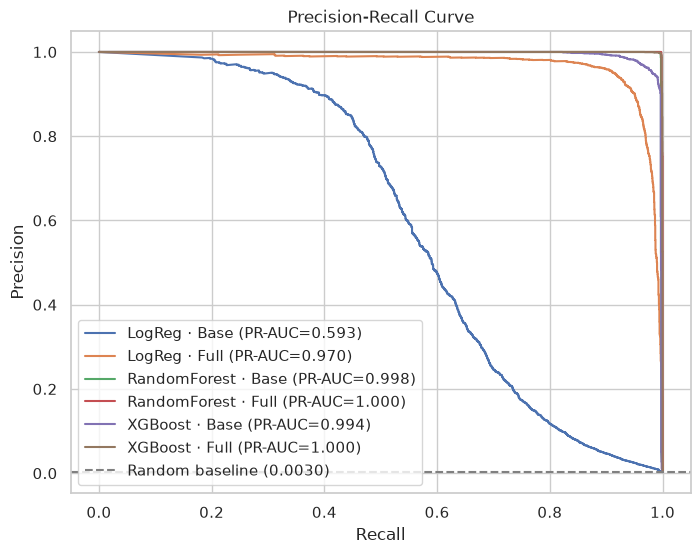

In [39]:
# Đường cong Precision-Recall so sánh các mô hình (Base vs Full)
fig, ax = plt.subplots(figsize=(8, 6))
for kq in ket_qua:
    precision, recall, _ = precision_recall_curve(y_test, kq["proba"])
    ax.plot(recall, precision, label=f"{kq['ten']} (PR-AUC={kq['pr_auc']:.3f})")

baseline = y_test.mean()
ax.axhline(baseline, color="gray", linestyle="--", label=f"Random baseline ({baseline:.4f})")
ax.set(title="Precision-Recall Curve", xlabel="Recall", ylabel="Precision")
ax.legend()
plt.show()

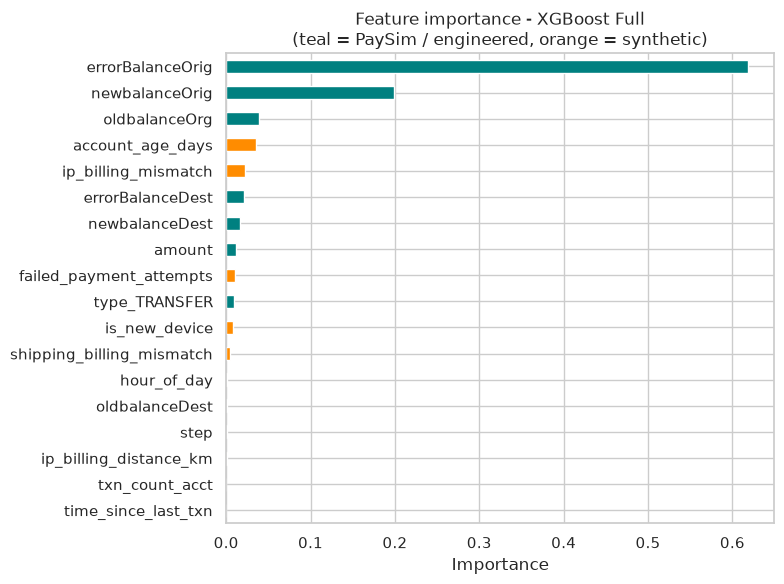

errorBalanceOrig             0.618358
newbalanceOrig               0.198310
oldbalanceOrg                0.039433
account_age_days             0.035734
ip_billing_mismatch          0.022745
errorBalanceDest             0.021044
newbalanceDest               0.016682
amount                       0.011831
failed_payment_attempts      0.010519
type_TRANSFER                0.009341
is_new_device                0.008039
shipping_billing_mismatch    0.004079
hour_of_day                  0.001486
oldbalanceDest               0.000960
step                         0.000720
ip_billing_distance_km       0.000719
txn_count_acct               0.000000
time_since_last_txn          0.000000
dtype: float32


In [40]:
# Độ quan trọng đặc trưng của XGBoost (mô hình Full)
importances = pd.Series(xgb_full.feature_importances_, index=full_cols).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["teal" if c in base_cols else "darkorange" for c in importances.index]
importances.plot(kind="barh", color=colors, ax=ax)
ax.set(title="Feature importance - XGBoost Full\n(teal = PaySim / engineered, orange = synthetic)", xlabel="Importance")
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False))

### 5.3 Tác động của dữ liệu tổng hợp & rủi ro rò rỉ nhãn

Bảng so sánh và đường PR ở trên cho thấy bộ **Full** (có tín hiệu tổng hợp) vượt trội bộ **Base** ở cả PR-AUC lẫn Recall. Cần diễn giải mức tăng này một cách thận trọng:

- ✅ **Về mặt nghiệp vụ, các tín hiệu này hợp lệ:** thiết bị lạ, lệch địa chỉ giao/thanh toán, IP khác quốc gia, số lần thanh toán thất bại… đều **quan sát được ngay tại thời điểm chấm giao dịch** (không phải thông tin tương lai). Đây đúng là loại đặc trưng rủi ro mà hệ thống thật dùng.
- ⚠️ **Nhưng có rò rỉ nhãn do cách sinh dữ liệu:** ở Module 1 chúng được rút ngẫu nhiên **có điều kiện theo `isFraud`** với khoảng cách xác suất lớn (vd p=0.55 vs 0.08). Do đó phần lớn sức mạnh dự báo là *cài sẵn theo thiết kế*. Trên dữ liệu thật, quan hệ giữa các tín hiệu này và gian lận gần như chắc chắn **yếu hơn và nhiễu hơn**.
- 👉 **Kết luận thực dụng:** điểm số của bộ Full nên xem là **cận trên lạc quan**; bộ **Base (chỉ PaySim)** phản ánh sát hơn độ khó thực tế. Khi báo cáo, trình bày **cả hai** và nêu rõ giới hạn này thay vì chỉ khoe điểm cao của bộ Full.

### 5.4 Metric theo chi phí & chọn ngưỡng vận hành

Chuyển đánh đổi Precision/Recall thành **tiền**: mỗi gian lận bỏ sót (FN) mất đúng **số tiền giao dịch**; mỗi cảnh báo giả (FP) tốn một khoản **ma sát/review cố định**. Quét ngưỡng để tối thiểu **tổng chi phí** — trả lời trực tiếp câu hỏi nghiệp vụ.

Áp dụng cho **XGBoost · Base** (mô hình trung thực, không rò rỉ) để có khuyến nghị triển khai đáng tin.

Ngưỡng tối ưu chi phí: 0.17 | tổng chi phí = 1,358,401 | Recall=0.997 Precision=0.902
Ngưỡng mặc định 0.50 :          | tổng chi phí = 1,591,668 | Recall=0.993 Precision=0.922

--- KPI tài chính (tập test) tại ngưỡng 0.17 ---
Tiền gian lận rủi ro gốc:  3,615,247,576
Tiền gian lận CHẶN được:   3,613,891,825 (100.0%)
Tiền gian lận còn lọt:     1,355,751
False-positive rate (FPR): 0.032%  (265 giao dịch hợp lệ bị chặn nhầm)
[TAB:COST] default cost=1,591,668 recall=0.9931 prec=0.9222 fp=206
[TAB:COST] optimal cost=1,358,401 recall=0.9967 prec=0.9024 fp=265
[TAB:COST] reduction=-14.66%


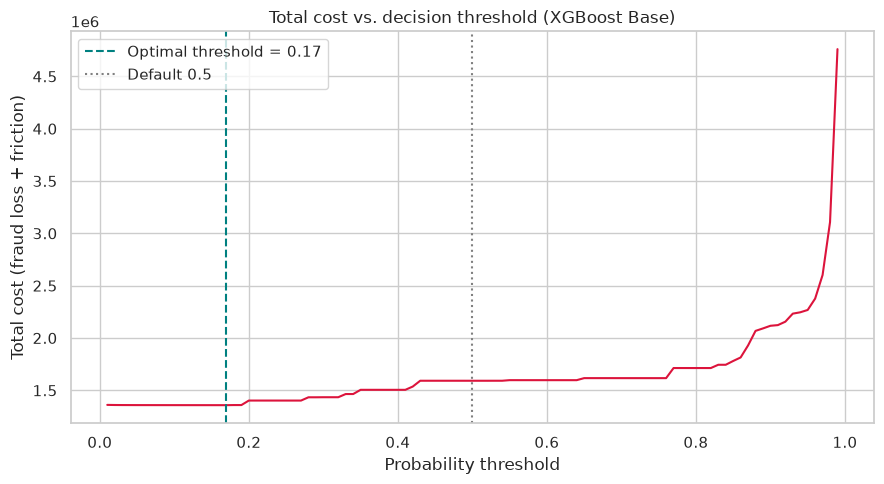

In [41]:
COST_FP = 10.0   # giả định: chi phí ma sát + review mỗi cảnh báo giả (đơn vị tiền)

proba_cost = xgb_base.predict_proba(X_test_base)[:, 1]
amt = X_test_base["amount"].to_numpy()
yt = y_test.to_numpy()

thresholds = np.linspace(0.01, 0.99, 99)
total_cost, recall_t, prec_t = [], [], []
for t in thresholds:
    pred = proba_cost >= t
    fn_loss = amt[(yt == 1) & (~pred)].sum()             # tiền mất do bỏ sót fraud
    fp_cost = COST_FP * int(((yt == 0) & pred).sum())    # chi phí cảnh báo giả
    total_cost.append(fn_loss + fp_cost)
    tp = int(((yt == 1) & pred).sum()); fp = int(((yt == 0) & pred).sum()); fn = int(((yt == 1) & ~pred).sum())
    recall_t.append(tp / (tp + fn) if tp + fn else 0.0)
    prec_t.append(tp / (tp + fp) if tp + fp else 0.0)
total_cost = np.array(total_cost)

best_i = int(total_cost.argmin())
best_t = thresholds[best_i]
i_half = int(np.argmin(np.abs(thresholds - 0.5)))
print(f"Ngưỡng tối ưu chi phí: {best_t:.2f} | tổng chi phí = {total_cost[best_i]:,.0f}"
      f" | Recall={recall_t[best_i]:.3f} Precision={prec_t[best_i]:.3f}")
print(f"Ngưỡng mặc định 0.50 :          | tổng chi phí = {total_cost[i_half]:,.0f}"
      f" | Recall={recall_t[i_half]:.3f} Precision={prec_t[i_half]:.3f}")

# KPI tài chính tại ngưỡng tối ưu
baseline_loss = amt[yt == 1].sum()
fraud_lost = amt[(yt == 1) & (proba_cost < best_t)].sum()
caught = baseline_loss - fraud_lost
fp_count = int(((yt == 0) & (proba_cost >= best_t)).sum())
fpr = fp_count / int((yt == 0).sum()) * 100
print(f"\n--- KPI tài chính (tập test) tại ngưỡng {best_t:.2f} ---")
print(f"Tiền gian lận rủi ro gốc:  {baseline_loss:,.0f}")
print(f"Tiền gian lận CHẶN được:   {caught:,.0f} ({caught/baseline_loss*100:.1f}%)")
print(f"Tiền gian lận còn lọt:     {fraud_lost:,.0f}")
print(f"False-positive rate (FPR): {fpr:.3f}%  ({fp_count:,} giao dịch hợp lệ bị chặn nhầm)")
fp_default = int(((yt == 0) & (proba_cost >= thresholds[i_half])).sum())
print(f"[TAB:COST] default cost={total_cost[i_half]:,.0f} recall={recall_t[i_half]:.4f} prec={prec_t[i_half]:.4f} fp={fp_default}")
print(f"[TAB:COST] optimal cost={total_cost[best_i]:,.0f} recall={recall_t[best_i]:.4f} prec={prec_t[best_i]:.4f} fp={fp_count}")
print(f"[TAB:COST] reduction={(total_cost[best_i]-total_cost[i_half])/total_cost[i_half]*100:.2f}%")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, total_cost, color="crimson")
ax.axvline(best_t, color="teal", linestyle="--", label=f"Optimal threshold = {best_t:.2f}")
ax.axvline(0.5, color="gray", linestyle=":", label="Default 0.5")
ax.set(title="Total cost vs. decision threshold (XGBoost Base)",
       xlabel="Probability threshold", ylabel="Total cost (fraud loss + friction)")
ax.legend(); plt.tight_layout(); plt.show()

### 5.5 Kết luận mô hình

- So sánh **3 thuật toán × 2 bộ đặc trưng** (mục 5.2): XGBoost tốt nhất, kế đến Random Forest, rồi Logistic Regression.
- Trên bộ **Base**, `errorBalanceOrig` áp đảo importance — khớp EDA; PaySim gần như tách được nên XGBoost Base đã rất mạnh.
- Bộ **Full** tăng thêm nhưng cần đọc kèm cảnh báo rò rỉ nhãn (5.3); trong XGBoost, tín hiệu tổng hợp có importance thấp → mô hình chủ yếu dựa vào đặc trưng thật.
- **Ngưỡng vận hành** đã chọn theo chi phí (mục 5.4) thay vì mặc định 0.5, phản ánh đánh đổi tiền-mất vs ma sát khách hàng.
- **Hạn chế:** điểm số cao một phần do PaySim dễ tách + dữ liệu tổng hợp gắn nhãn → hiệu năng thực tế sẽ thấp hơn; báo cáo cần nêu rõ giới hạn này.
- **Cải tiến tiếp:** thử SMOTE/undersampling, tinh chỉnh siêu tham số (RandomizedSearchCV, `scoring="average_precision"`).

## Module 6 — Deployment (API + Streamlit demo)

Export mô hình **XGBoost Base** (gọn, không rò rỉ) ra `deployment/model.joblib` để phục vụ:
- **API real-time** (`deployment/api.py`, FastAPI) — endpoint `/predict`.
- **UI hàng đợi review** (`deployment/app.py`, Streamlit).

Feature phục vụ được rút gọn (bỏ `step` & velocity vốn cần lịch sử) → API chỉ nhận field thô của 1 giao dịch, tự suy `errorBalance*` và `type_TRANSFER`. Ngưỡng chặn chọn theo tối ưu chi phí (mục 5.4). Xem `deployment/README.md` để chạy local & deploy Hugging Face Spaces.

In [42]:
import os, joblib

# Feature gọn cho API real-time (bỏ step & velocity cần lịch sử tài khoản)
DEPLOY_FEATURES = [
    "amount",
    "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest",
    "errorBalanceOrig", "errorBalanceDest",
    "type_TRANSFER",
]

Xd_tr = X_train_full[DEPLOY_FEATURES]
Xd_te = X_test_full[DEPLOY_FEATURES]

deploy_model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
    n_jobs=-1, random_state=42,
).fit(Xd_tr, y_train)

# Chọn ngưỡng tối thiểu chi phí (cùng công thức mục 5.4)
proba_d = deploy_model.predict_proba(Xd_te)[:, 1]
amt = Xd_te["amount"].to_numpy(); yt = y_test.to_numpy()
ths = np.linspace(0.01, 0.99, 99)
costs = [amt[(yt == 1) & (proba_d < t)].sum() + 10.0 * int(((yt == 0) & (proba_d >= t)).sum()) for t in ths]
deploy_threshold = float(ths[int(np.argmin(costs))])

pr_auc = average_precision_score(yt, proba_d)
print(f"Deploy model - PR-AUC={pr_auc:.4f} | nguong chan={deploy_threshold:.2f} | {len(DEPLOY_FEATURES)} dac trung")

# Ngưỡng auto-block (chính sách rủi ro 3 mức): điểm nhỏ nhất mà precision trên test >= 0.99
# -> chỉ chặn TỰ ĐỘNG khi mô hình gần như chắc chắn; vùng [deploy_threshold, block) đẩy sang review thủ công.
from sklearn.metrics import precision_score
block_threshold = 0.80
for _t in np.linspace(deploy_threshold, 0.99, 80):
    _pred = (proba_d >= _t).astype(int)
    if _pred.sum() and precision_score(yt, _pred, zero_division=0) >= 0.99:
        block_threshold = float(_t); break
block_threshold = round(max(block_threshold, deploy_threshold + 0.05), 4)
print(f"Nguong auto-block (precision>=0.99 tren test): {block_threshold:.2f}")

os.makedirs("deployment", exist_ok=True)
joblib.dump({
    "model": deploy_model,
    "features": DEPLOY_FEATURES,
    "threshold": deploy_threshold,
    "block_threshold": block_threshold,
    "model_name": "XGBoost Base (deploy)",
}, "deployment/model.joblib")
print("Da luu deployment/model.joblib - san sang cho API & Streamlit.")

Deploy model - PR-AUC=0.9920 | nguong chan=0.09 | 8 dac trung


Nguong auto-block (precision>=0.99 tren test): 0.80
Da luu deployment/model.joblib - san sang cho API & Streamlit.


## Module 7 — Giám sát mô hình (Model Monitoring)

Sau khi triển khai, mô hình phải được **giám sát** để phát hiện khi dữ liệu thực tế trôi khỏi phân phối huấn luyện (*data drift*) và khi hiệu năng suy giảm theo thời gian.

Ta giám sát 3 khía cạnh và định nghĩa **ngưỡng kích hoạt huấn luyện lại**:

1. **Data drift** — so sánh phân phối 8 đặc trưng phục vụ giữa cửa sổ *tham chiếu* (lúc huấn luyện) và cửa sổ *hiện tại* (giao dịch đến), bằng chỉ số **PSI** và kiểm định **Kolmogorov–Smirnov**.
2. **Hiệu năng theo thời gian** — precision / recall / PR-AUC trên **cửa sổ trượt** theo `step`.
3. **Kích hoạt huấn luyện lại** — quy tắc ngưỡng cụ thể (PSI, độ phủ drift, sàn recall/precision, sụt PR-AUC).

> PaySim chỉ có một mốc thời gian nên ta **mô phỏng dòng dữ liệu đến** bằng cách chia `step` làm đôi (nửa đầu = tham chiếu, nửa sau = hiện tại). Logic giám sát nằm ở `monitoring/monitoring_core.py` (tự cài đặt, không phụ thuộc thư viện dashboard nặng — tương đương những gì Evidently cung cấp). Dashboard HTML độc lập sinh bằng `python monitoring/build_monitoring.py` (hoặc `pixi run monitor`) → `monitoring/monitoring_report.html`.

In [43]:
# ---- Module 7: giám sát drift + hiệu năng theo thời gian ----
import sys, os
sys.path.insert(0, "monitoring")
from monitoring_core import (DEPLOY_FEATURES, drift_report, rolling_performance,
                             evaluate_triggers, DEFAULT_TRIGGERS)

# Chấm điểm tập test (holdout) bằng mô hình triển khai; dùng `step` làm trục thời gian
mon = X_test_full[DEPLOY_FEATURES].copy()
mon["step"]    = model_df.loc[X_test_full.index, "step"].to_numpy()
mon["isFraud"] = y_test.to_numpy()
mon["score"]   = deploy_model.predict_proba(mon[DEPLOY_FEATURES])[:, 1]

# Mô phỏng "dòng giao dịch đến": nửa thời gian đầu = tham chiếu, nửa sau = hiện tại
cut = mon["step"].median()
ref = mon[mon["step"] <= cut].copy()
cur = mon[mon["step"] >  cut].copy()
print(f"Tham chiếu: {len(ref):,} gd (step <= {cut:.0f})  |  Hiện tại: {len(cur):,} gd (step > {cut:.0f})")

# 1) Data drift trên 8 đặc trưng phục vụ
drift = drift_report(ref, cur, DEPLOY_FEATURES)
print("\n== DATA DRIFT (PSI & KS) ==")
print(drift.round(4).to_string(index=False))
print(f"Số đặc trưng lệch: {int(drift['drifted'].sum())}/{len(drift)}")

# 2) Hiệu năng trên cửa sổ trượt theo thời gian
ref_pr_auc = float(average_precision_score(ref["isFraud"], ref["score"]))
perf = rolling_performance(mon, "step", "isFraud", "score", deploy_threshold, n_windows=12)
print("\n== HIỆU NĂNG THEO CỬA SỔ THỜI GIAN ==")
print(perf[["window_start","n","n_fraud","precision","recall","pr_auc"]].round(4).to_string(index=False))

# 3) Đánh giá ngưỡng kích hoạt huấn luyện lại
trig = evaluate_triggers(drift, perf, ref_pr_auc)
print(f"\n== KÍCH HOẠT HUẤN LUYỆN LẠI: {trig['retrain_recommended']} ==")
for r in trig["reasons"]:
    print("  -", r)
if not trig["reasons"]:
    print("  (mọi chỉ số trong ngưỡng an toàn — chưa cần huấn luyện lại)")

# Xuất dữ liệu đã chấm điểm cho dashboard độc lập & báo cáo
os.makedirs("monitoring", exist_ok=True)
cols = DEPLOY_FEATURES + ["step", "isFraud", "score"]
ref[cols].to_parquet("monitoring/reference_scored.parquet", index=False)
cur[cols].to_parquet("monitoring/current_scored.parquet", index=False)
print("\nĐã lưu monitoring/reference_scored.parquet & current_scored.parquet")

Tham chiếu: 416,418 gd (step <= 236)  |  Hiện tại: 414,700 gd (step > 236)



== DATA DRIFT (PSI & KS) ==
         feature    psi  ks_stat  ks_pvalue     ref_mean     cur_mean  drifted
errorBalanceDest 0.1664   0.0821     0.0000  -30170.5544  -26443.6453    False
  newbalanceDest 0.0073   0.0216     0.0000 1808216.0062 2303639.2248    False
  oldbalanceDest 0.0045   0.0187     0.0000 1511505.6442 1906636.8316    False
          amount 0.0033   0.0192     0.0000  266539.8076  370558.7479    False
errorBalanceOrig 0.0027   0.0190     0.0000  235423.9590  338339.9785    False
   oldbalanceOrg 0.0007   0.0069     0.0000   48594.2741   46989.6126    False
   type_TRANSFER 0.0005   0.0092     0.0000       0.1881       0.1973    False
  newbalanceOrig 0.0000   0.0049     0.0001   17478.4255   14770.8432    False
Số đặc trưng lệch: 0/8



== HIỆU NĂNG THEO CỬA SỔ THỜI GIAN ==
 window_start      n  n_fraud  precision  recall  pr_auc
        0.259 135993      213     0.7610  0.9718  0.9574
       62.750   3737      228     0.9956  1.0000  0.9997
      124.500 157983      193     0.7649  0.9948  0.9887
      186.250 122742      226     0.8248  1.0000  0.9911
      248.000 153518      205     0.7885  1.0000  0.9916
      309.750 114843      199     0.8122  1.0000  0.9916
      371.500  98362      208     0.8560  1.0000  0.9931
      433.250   5650      179     0.9834  0.9944  0.9981
      495.000  13742      198     0.9851  1.0000  0.9998
      556.750  12482      214     0.9682  0.9953  0.9979
      618.500   3334      194     0.9847  0.9948  0.9991
      680.250   8732      202     0.9854  1.0000  0.9999

== KÍCH HOẠT HUẤN LUYỆN LẠI: False ==
  (mọi chỉ số trong ngưỡng an toàn — chưa cần huấn luyện lại)



Đã lưu monitoring/reference_scored.parquet & current_scored.parquet


In [44]:
# ---- Lưu hình giám sát cho báo cáo + kiểm thử chịu tải cơ chế cảnh báo ----
import build_monitoring as bm
bm.REF_DF, bm.CUR_DF = ref, cur
os.makedirs("report/figures", exist_ok=True)
bm.drift_figure(drift, ref, cur).savefig("report/figures/monitoring_drift.png", dpi=150, bbox_inches="tight")
bm.performance_figure(perf, deploy_threshold).savefig("report/figures/monitoring_performance.png", dpi=150, bbox_inches="tight")
print("Đã lưu report/figures/monitoring_drift.png & monitoring_performance.png")

# Kiểm thử chịu tải: tiêm drift nhân tạo (số tiền x2.5, sai số số dư tăng) để xác nhận
# cơ chế cảnh báo & kích hoạt huấn luyện lại hoạt động đúng khi drift thực sự xảy ra.
cur_shift = cur.copy()
cur_shift["amount"]           = cur_shift["amount"] * 2.5
cur_shift["errorBalanceOrig"] = cur_shift["errorBalanceOrig"] + cur_shift["amount"] * 0.3
drift_stress = drift_report(ref, cur_shift, DEPLOY_FEATURES)
perf_stress  = perf.assign(recall=perf["recall"] * 0.5)          # giả lập recall tụt
trig_stress  = evaluate_triggers(drift_stress, perf_stress, ref_pr_auc)
print(f"[kiểm thử chịu tải] retrain = {trig_stress['retrain_recommended']} "
      f"| đặc trưng lệch = {int(drift_stress['drifted'].sum())}/{len(drift_stress)}")
for r in trig_stress["reasons"]:
    print("   -", r)

Đã lưu report/figures/monitoring_drift.png & monitoring_performance.png


[kiểm thử chịu tải] retrain = True | đặc trưng lệch = 2/8
   - Data drift: max PSI 1.344 > 0.2 on 'errorBalanceOrig'.
   - Breadth of drift: 2 served features flagged (>= 2).
   - Recall breach: rolling recall fell to 0.486 < floor 0.9.


### 7.1 Diễn giải & chính sách huấn luyện lại

**Kết quả giám sát** (bảng & hình ở trên) gồm: (i) PSI + KS cho từng đặc trưng phục vụ, (ii) precision/recall/PR-AUC theo 12 cửa sổ thời gian, (iii) phán quyết kích hoạt.

**Ngưỡng kích hoạt huấn luyện lại** (định nghĩa trong `DEFAULT_TRIGGERS`, `monitoring/monitoring_core.py`):

| Tín hiệu | Ngưỡng | Ý nghĩa |
|---|---|---|
| PSI tối đa | `> 0.20` | một đặc trưng phục vụ lệch phân phối đáng kể |
| Độ phủ drift | `>= 2` đặc trưng bị gắn cờ | drift lan rộng, không phải nhiễu đơn lẻ |
| Sàn recall (trượt) | `< 0.90` | bỏ sót quá nhiều gian lận |
| Sàn precision (trượt) | `< 0.20` | quá nhiều cảnh báo giả (ma sát khách hàng) |
| Sụt PR-AUC | `> 0.10` dưới tham chiếu | năng lực xếp hạng suy giảm |

Khi **bất kỳ** điều kiện nào kích hoạt → xếp hàng **huấn luyện lại** (thu thập nhãn mới, tái huấn luyện trên cửa sổ gần đây, kiểm định ngược rồi triển khai). Phần **kiểm thử chịu tải** ở trên tiêm drift nhân tạo để chứng minh cơ chế cảnh báo phản ứng đúng.

> **Vận hành thực tế:** ghi log mọi giao dịch được chấm điểm + nhãn về sau, chạy `pixi run monitor` định kỳ (cron/CI) để cập nhật `monitoring/monitoring_report.html`, và gắn cảnh báo khi `retrain_recommended = True`.

## Phụ lục — Xuất hình cho báo cáo LaTeX (nhãn tiếng Anh)

Vẽ lại 5 biểu đồ chính với nhãn **tiếng Anh** và lưu vào `report/figures/`
để chèn vào báo cáo `report/main.tex`. Chạy cell này **sau khi đã chạy hết
Module 5** (cần `ket_qua`, `xgb_full`, `thresholds`, `total_cost`, `best_t`).

Tên file giữ nguyên nên LaTeX không cần sửa gì — chỉ ghi đè ảnh cũ.

In [45]:
import os

FIGDIR = "report/figures"
os.makedirs(FIGDIR, exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(f"{FIGDIR}/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

# ---- 1. Phan bo amount theo nhan ----
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(np.log1p(df.loc[df.isFraud == 0, "amount"]), bins=60, color="steelblue",
             label="Legitimate", stat="density", alpha=0.6, ax=ax)
sns.histplot(np.log1p(df.loc[df.isFraud == 1, "amount"]), bins=60, color="crimson",
             label="Fraud", stat="density", alpha=0.6, ax=ax)
ax.set(title="Distribution of log(1 + amount) by class",
       xlabel="log(1 + amount)", ylabel="Density")
ax.legend()
save_fig("amount_distribution")

# ---- 2. Fraud rate theo co rui ro ----
flags = ["is_new_device", "shipping_billing_mismatch", "ip_billing_mismatch"]
rows = []
for f in flags:
    g = df.groupby(f)["isFraud"].mean() * 100
    rows.append({"Flag": f, "Flag = 0": g.get(0, 0.0), "Flag = 1": g.get(1, 0.0)})
flag_df = pd.DataFrame(rows).set_index("Flag")

ax = flag_df.plot(kind="bar", figsize=(9, 5), color=["steelblue", "crimson"])
ax.set(title="Fraud rate by synthetic risk flag", ylabel="Fraud rate (%)", xlabel="")
ax.legend(title="Flag value")
plt.xticks(rotation=12)
save_fig("fraud_rate_flags")

# ---- 3. Precision-Recall curves (6 mo hinh) ----
fig, ax = plt.subplots(figsize=(8, 6))
for kq in ket_qua:
    precision, recall, _ = precision_recall_curve(y_test, kq["proba"])
    ax.plot(recall, precision, label=f"{kq['ten']} (PR-AUC={kq['pr_auc']:.3f})")
baseline = y_test.mean()
ax.axhline(baseline, color="gray", linestyle="--", label=f"Random baseline ({baseline:.4f})")
ax.set(title="Precision-Recall Curve", xlabel="Recall", ylabel="Precision")
ax.legend()
save_fig("pr_curves")

# ---- 4. Feature importance ----
importances = pd.Series(xgb_full.feature_importances_, index=full_cols).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["teal" if c in base_cols else "darkorange" for c in importances.index]
importances.plot(kind="barh", color=colors, ax=ax)
ax.set(title="Feature importance - XGBoost Full\n(teal = PaySim / engineered, orange = synthetic)",
       xlabel="Importance")
save_fig("feature_importance")

# ---- 5. Cost vs threshold ----
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, total_cost, color="crimson")
ax.axvline(best_t, color="teal", linestyle="--", label=f"Optimal threshold = {best_t:.2f}")
ax.axvline(0.5, color="gray", linestyle=":", label="Default 0.5")
ax.set(title="Total cost vs. decision threshold (XGBoost Base)",
       xlabel="Probability threshold", ylabel="Total cost (fraud loss + friction)")
ax.legend()
save_fig("cost_threshold")

print(f"Da luu 5 hinh (nhan tieng Anh) vao {FIGDIR}/")

/tmp/ipykernel_1949225/1424347054.py:7: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


/tmp/ipykernel_1949225/1424347054.py:8: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f"{FIGDIR}/{name}.png", dpi=150, bbox_inches="tight")


Da luu 5 hinh (nhan tieng Anh) vao report/figures/
